## Importing Libraries

In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Read Data and Statistics

In [252]:
df = pd.read_csv("final_internship_data.csv")

In [253]:
df.head()

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [295]:
df.dtypes

Car Condition          object
Weather                object
Traffic Condition      object
fare_amount           float64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
passenger_count       float64
hour                    int64
day                     int64
month                   int64
weekday                 int64
year                    int64
jfk_dist              float64
ewr_dist              float64
lga_dist              float64
sol_dist              float64
nyc_dist              float64
distance              float64
bearing               float64
distance_category    category
trip_type              object
season                 object
dtype: object

In [254]:
df.columns

Index(['User ID', 'User Name', 'Driver Name', 'Car Condition', 'Weather',
       'Traffic Condition', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'hour', 'day', 'month',
       'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist',
       'nyc_dist', 'distance', 'bearing'],
      dtype='object')

In [255]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

There appear to be NULL values

In [256]:
df.isnull().sum()

User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64

In [257]:
df[df.isnull().any(axis=1)]

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
120227,BOLML7gg,Carol Kim,John Scott,Very Good,rainy,Dense Traffic,2012-12-11 12:57:00.00000013,12.5,2012-12-11 12:57:00,-1.291417,...,12,1,2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245696,AA838qgm,Mark Jones,Christy Taylor,Bad,windy,Dense Traffic,2013-03-21 18:07:07.0000001,86.5,2013-03-21 18:07:07,-1.291397,...,3,3,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
340533,BqrlHUr2,Joshua Mullins,Sarah Khan,Excellent,cloudy,Dense Traffic,2012-12-11 12:50:52.00000010,27.5,2012-12-11 12:50:52,-1.291188,...,12,1,2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
428108,rL4WTHGq,Richard Brown,Rachel Miller,Very Good,cloudy,Flow Traffic,2011-09-08 09:12:52.0000001,11.8,2011-09-08 09:12:52,-1.291317,...,9,3,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN
471472,tKIOKS8Y,Larry Wade,Howard Jackson,Good,windy,Congested Traffic,2012-12-11 12:34:20.0000006,7.8,2012-12-11 12:34:20,0.000000,...,12,1,2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN


All the nulls are in the same 5 rows so it is safe to delete them

In [258]:
df.dropna(inplace=True)

In [259]:
df.isnull().sum()

User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             0
ewr_dist             0
lga_dist             0
sol_dist             0
nyc_dist             0
distance             0
bearing              0
dtype: int64

In [260]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499995 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            499995 non-null  object 
 1   User Name          499995 non-null  object 
 2   Driver Name        499995 non-null  object 
 3   Car Condition      499995 non-null  object 
 4   Weather            499995 non-null  object 
 5   Traffic Condition  499995 non-null  object 
 6   key                499995 non-null  object 
 7   fare_amount        499995 non-null  float64
 8   pickup_datetime    499995 non-null  object 
 9   pickup_longitude   499995 non-null  float64
 10  pickup_latitude    499995 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    499995 non-null  int64  
 14  hour               499995 non-null  int64  
 15  day                499995 non-null  int64  
 16  month  

In [261]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000
mean,11.358182,-1.265714,0.696742,-1.265755,0.696675,1.683445,13.510843,15.684239,6.268617,3.042020,2011.739129,385.279367,380.503657,363.843772,363.674038,355.991423,19.468775,0.297145
std,9.916069,0.206934,0.140906,0.205903,0.128997,1.307391,6.511596,8.681092,3.437798,1.949243,1.860897,2419.087483,2428.804740,2425.075903,2428.348683,2428.730839,367.299601,1.804548
min,-44.900000,-52.119764,-54.389440,-59.049665,-44.676047,0.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,-3.141593
25%,6.000000,-1.291405,0.710958,-1.291393,0.710943,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.341514,32.173712,17.100762,14.886989,7.147384,1.214550,-0.854721
50%,8.500000,-1.291226,0.711268,-1.291197,0.711277,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.523163,34.787507,19.591554,18.347580,10.458151,2.116970,-0.050442
75%,12.500000,-1.290970,0.711520,-1.290908,0.711538,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.785649,38.304502,22.214815,22.417812,14.448699,3.890070,2.206769
max,500.000000,37.360538,29.724576,0.712985,7.061893,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,30133.067880,30167.595967,30167.285794,30159.407296,30162.285356,12399.956433,3.141593


In [262]:
df.apply(lambda x: x.duplicated().sum())

User ID                   0
User Name            278322
Driver Name          278295
Car Condition        499991
Weather              499990
Traffic Condition    499992
key                       0
fare_amount          498307
pickup_datetime       38794
pickup_longitude     404958
pickup_latitude      380880
dropoff_longitude    391712
dropoff_latitude     364942
passenger_count      499988
hour                 499971
day                  499964
month                499983
weekday              499988
year                 499988
jfk_dist               9382
ewr_dist               9382
lga_dist               9382
sol_dist               9382
nyc_dist               9382
distance              14290
bearing               14359
dtype: int64

In [263]:
df[df.duplicated(subset='User Name', keep=False)].sort_values(by='User Name')

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
496174,nvofl4vB,Aaron Adams,John Williams,Good,cloudy,Congested Traffic,2014-02-03 14:56:38.0000003,6.0,2014-02-03 14:56:38,-1.291431,...,2,0,2014,44.617998,32.609242,21.087610,17.106299,9.530705,1.398795,3.043334
457331,gM42XZkq,Aaron Adams,Amy Smith,Excellent,rainy,Dense Traffic,2012-03-21 22:22:51.0000001,8.1,2012-03-21 22:22:51,-1.290668,...,3,2,2012,44.127157,39.166859,15.701951,23.960269,16.017994,2.698550,1.544734
316852,nHvIqdtV,Aaron Adams,Jennifer Rogers,Very Good,stormy,Dense Traffic,2013-09-07 22:12:37.0000007,7.0,2013-09-07 22:12:37,-1.290251,...,9,5,2013,30.582579,39.493835,18.624047,18.959587,12.049659,2.026781,0.925633
142439,hEBOdcK6,Aaron Adams,Adam Mann,Excellent,stormy,Dense Traffic,2014-11-23 11:52:07.0000004,11.0,2014-11-23 11:52:07,-1.291290,...,11,6,2014,42.309147,34.226768,19.390641,17.466500,9.293379,2.937478,-0.231396
190728,iwoQUA1Z,Aaron Adams,Emily Higgins,Good,windy,Congested Traffic,2009-11-19 18:25:47.0000004,7.7,2009-11-19 18:25:47,-1.290728,...,11,3,2009,43.544848,41.139432,14.144941,25.609146,17.452469,2.020582,2.958536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329530,mu0VwTw2,Zoe Rodriguez,Eric Mann,Bad,stormy,Dense Traffic,2011-04-29 09:20:00.0000002,3.7,2011-04-29 09:20:00,-1.291226,...,4,4,2011,42.045832,34.349987,19.016418,17.559664,9.367077,0.538389,-0.546730
115403,TFSvvajj,Zoe Smith,Natalie Burke,Good,stormy,Flow Traffic,2013-08-06 18:56:14.0000003,8.0,2013-08-06 18:56:14,-1.291335,...,8,1,2013,41.842741,30.344140,23.192673,12.366673,4.188274,1.574641,2.152598
255545,6fVLsnqo,Zoe Smith,Katherine Brown,Very Good,windy,Congested Traffic,2010-10-18 20:51:10.0000001,8.9,2010-10-18 20:51:10,-1.291134,...,10,0,2010,42.916355,33.660366,19.946904,17.129114,9.086028,3.264641,2.672916
424741,KxWGsf7w,Zoe White,Stephanie Flores,Bad,windy,Flow Traffic,2010-11-12 13:59:00.000000188,7.7,2010-11-12 13:59:00,-1.290705,...,11,4,2010,42.010596,40.493853,13.754081,24.305850,16.026713,1.105680,0.309531


Are User's with the same name but diffrent user ???
Probably not and that concludes that we don't need the User ID, User Name and Driver Name and key

In [264]:
df = df.drop(columns=['User ID' ,'User Name', 'Driver Name', 'key'])
print(df.columns)
df.head()

Index(['Car Condition', 'Weather', 'Traffic Condition', 'fare_amount',
       'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour',
       'day', 'month', 'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist',
       'sol_dist', 'nyc_dist', 'distance', 'bearing'],
      dtype='object')


,Car Condition,Weather,Traffic Condition,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,Very Good,windy,Congested Traffic,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,1,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,Excellent,cloudy,Flow Traffic,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,1,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,Bad,stormy,Congested Traffic,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,2,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,Very Good,stormy,Flow Traffic,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,1,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,Bad,stormy,Congested Traffic,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,1,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [265]:
df[['pickup_datetime', 'hour', 'day', 'month', 'year', 'weekday']].head(10)

,pickup_datetime,hour,day,month,year,weekday
0,2009-06-15 17:26:21,17,15,6,2009,0
1,2010-01-05 16:52:16,16,5,1,2010,1
2,2011-08-18 00:35:00,0,18,8,2011,3
3,2012-04-21 04:30:42,4,21,4,2012,5
4,2010-03-09 07:51:00,7,9,3,2010,1
5,2011-01-06 09:50:45,9,6,1,2011,3
6,2012-11-20 20:35:00,20,20,11,2012,1
7,2012-01-04 17:22:00,17,4,1,2012,2
8,2012-12-03 13:10:00,13,3,12,2012,0
9,2009-09-02 01:11:00,1,2,9,2009,2


The information in pickup_datatime is present in other columns so it is OK to remove it

In [266]:
df = df.drop(columns=['pickup_datetime'])
print(df.columns)
df.head()

Index(['Car Condition', 'Weather', 'Traffic Condition', 'fare_amount',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'hour', 'day', 'month',
       'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist',
       'nyc_dist', 'distance', 'bearing'],
      dtype='object')


,Car Condition,Weather,Traffic Condition,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,Very Good,windy,Congested Traffic,4.5,-1.288826,0.710721,-1.288779,0.710563,1,17,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,Excellent,cloudy,Flow Traffic,16.9,-1.291824,0.710546,-1.291182,0.711780,1,16,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,Bad,stormy,Congested Traffic,5.7,-1.291242,0.711418,-1.291391,0.711231,2,0,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,Very Good,stormy,Flow Traffic,7.7,-1.291319,0.710927,-1.291396,0.711363,1,4,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,Bad,stormy,Congested Traffic,5.3,-1.290987,0.711536,-1.290787,0.711811,1,7,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


## Univariate Analysis

### Disturbutions

#### Categorical Features

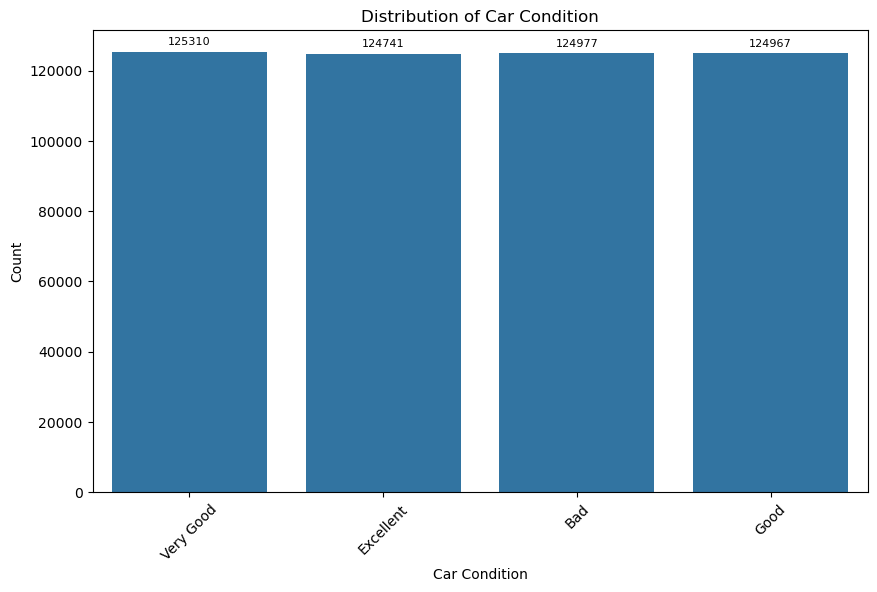

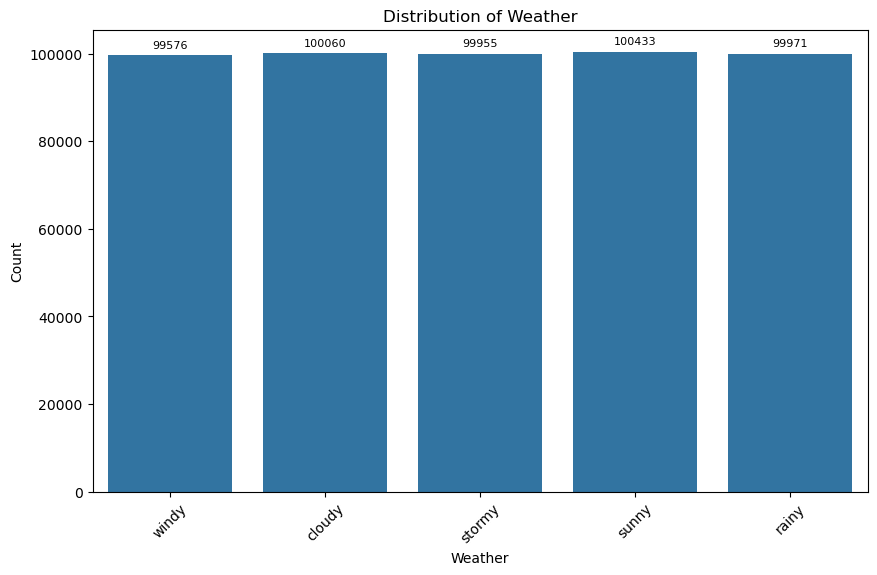

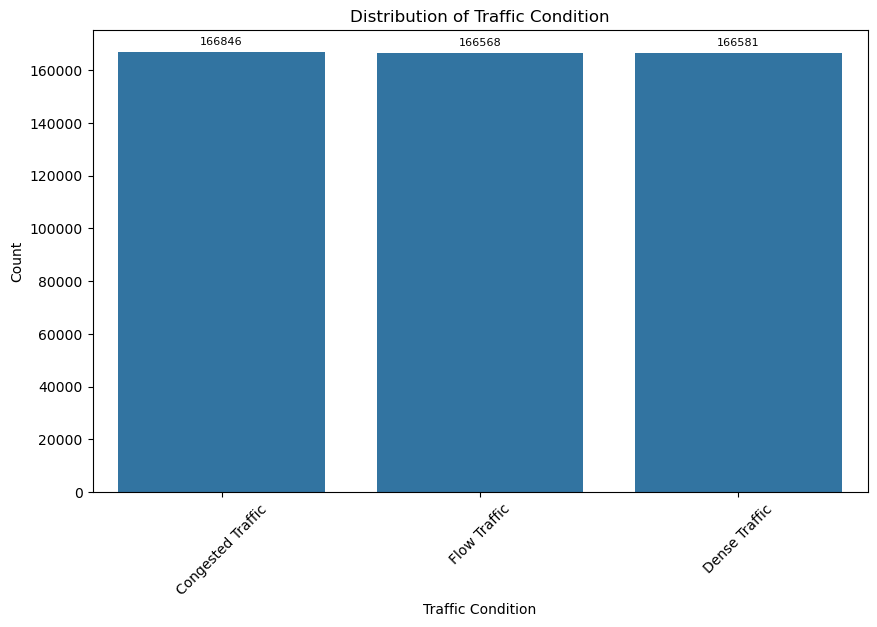

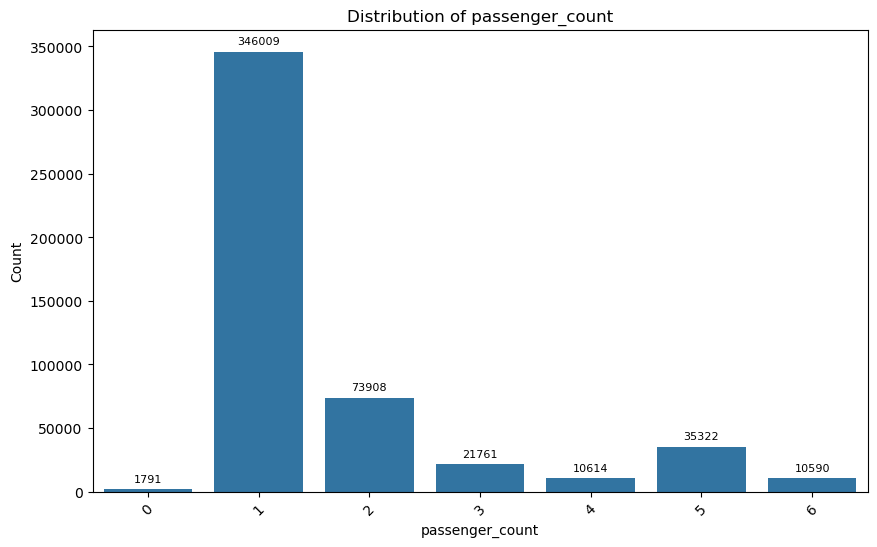

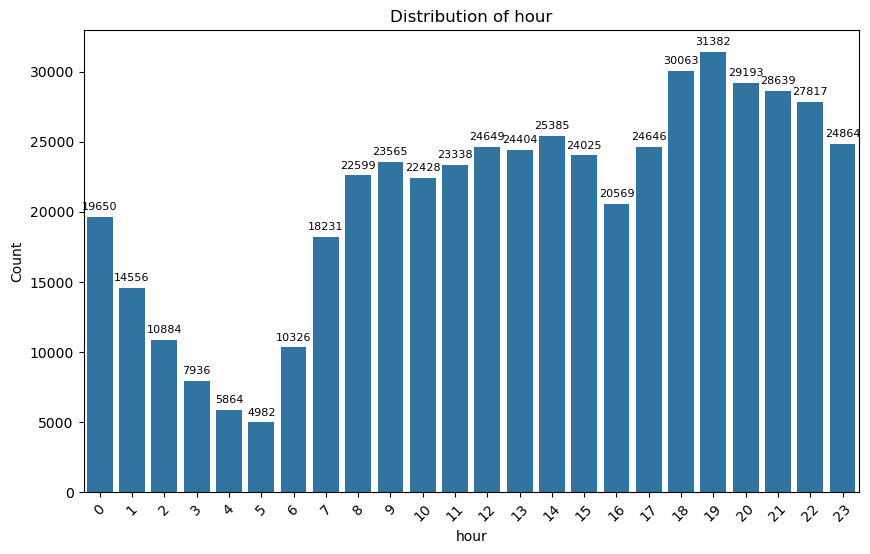

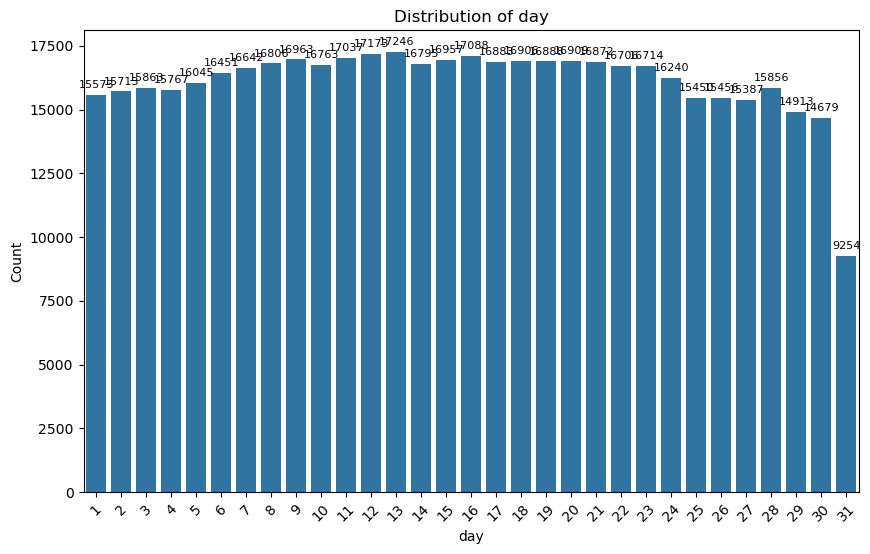

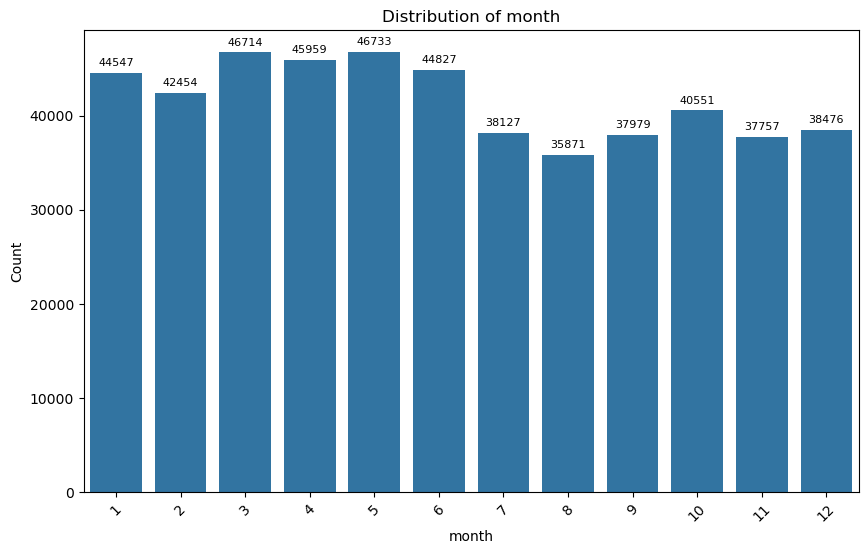

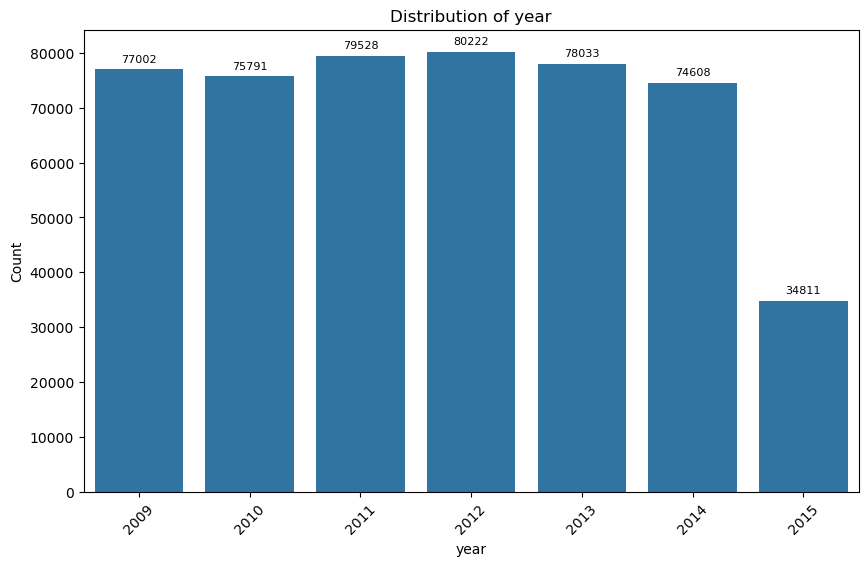

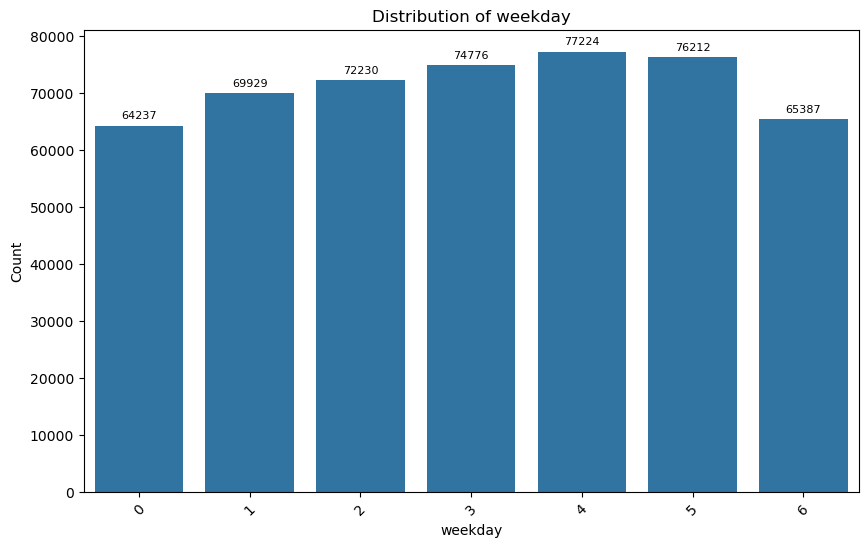

In [267]:
categorical = ['Car Condition', 'Weather', 'Traffic Condition', 'passenger_count', 'hour', 'day', 'month', 'year', 'weekday']

for feature in categorical:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df, x=feature)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=8, color='black', xytext=(0, 5),
                    textcoords='offset points')
    plt.show()

0 Passengers ?????

In [268]:
records_with_zero_passengers = df[df['passenger_count'] == 0]
records_with_zero_passengers

,Car Condition,Weather,Traffic Condition,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
314,Very Good,rainy,Congested Traffic,34.0,-1.291106,0.711241,-1.289947,0.713523,0,23,...,6,1,2015,49.707029,47.954794,21.112890,33.333532,25.275227,15.577567,-0.366230
566,Good,stormy,Dense Traffic,4.9,-1.290764,0.711795,-1.290772,0.711635,0,21,...,1,5,2012,42.857164,40.662335,14.007863,24.844038,16.635168,1.020108,3.102373
678,Bad,windy,Flow Traffic,6.5,-1.291254,0.711015,-1.291044,0.711362,0,7,...,2,0,2012,41.315595,34.561818,18.882275,17.320243,8.997916,2.426752,-0.429661
1160,Bad,rainy,Flow Traffic,13.3,-1.291515,0.711053,-1.290609,0.711699,0,23,...,5,2,2011,42.449216,36.264752,17.576321,19.708428,11.640352,6.003251,-0.815443
1935,Very Good,sunny,Congested Traffic,10.1,-1.291044,0.712007,-1.290983,0.711546,0,11,...,10,6,2011,45.122314,39.058836,16.629750,24.215571,16.325672,2.950300,-3.041521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497498,Bad,rainy,Dense Traffic,6.5,-1.291371,0.711080,-1.291142,0.711372,0,15,...,7,0,2011,42.422735,33.757034,19.680021,17.027286,8.901994,2.160094,-0.536110
498198,Excellent,windy,Flow Traffic,15.7,-1.291657,0.710595,-1.291336,0.711190,0,11,...,2,4,2012,42.268758,30.298109,23.537613,12.332875,4.099683,4.098189,-0.388204
498303,Very Good,cloudy,Congested Traffic,9.7,-1.291111,0.711321,-1.291308,0.711007,0,18,...,11,6,2011,41.599192,33.899806,19.518506,16.701350,8.421090,2.216350,2.697586
498342,Very Good,sunny,Flow Traffic,9.7,0.000000,0.000000,0.000000,0.000000,0,8,...,1,0,2012,17293.486312,17360.264559,17314.695444,17339.554005,17334.256605,0.000000,0.000000


They seem like good data and there is 1791 of them, so lets apply them by the mode

In [269]:
# Calculate the mean of the passenger_count column, excluding zeros
mean_passenger_count = df[df['passenger_count'] != 0]['passenger_count'].mode()

# Replace records with 0 passengers with the calculated mean
df.loc[df['passenger_count'] == 0, 'passenger_count'] = mean_passenger_count

(df['passenger_count'] == 0).sum()

0

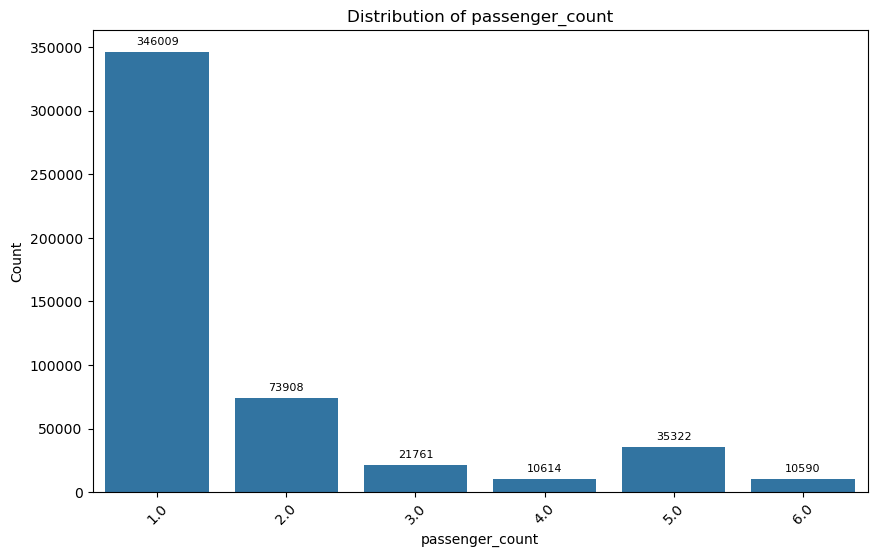

In [270]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='passenger_count')
plt.title(f'Distribution of passenger_count')
plt.xlabel('passenger_count')
plt.ylabel('Count')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=8, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

We might need to resample passenger_count due to its skewness

#### Numerical Features

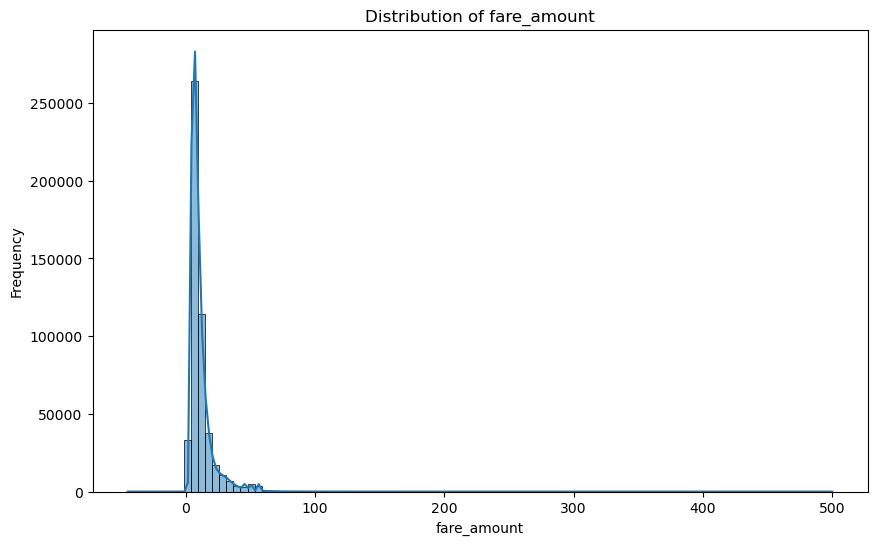

Skewness of fare_amount: 4.898310844940079


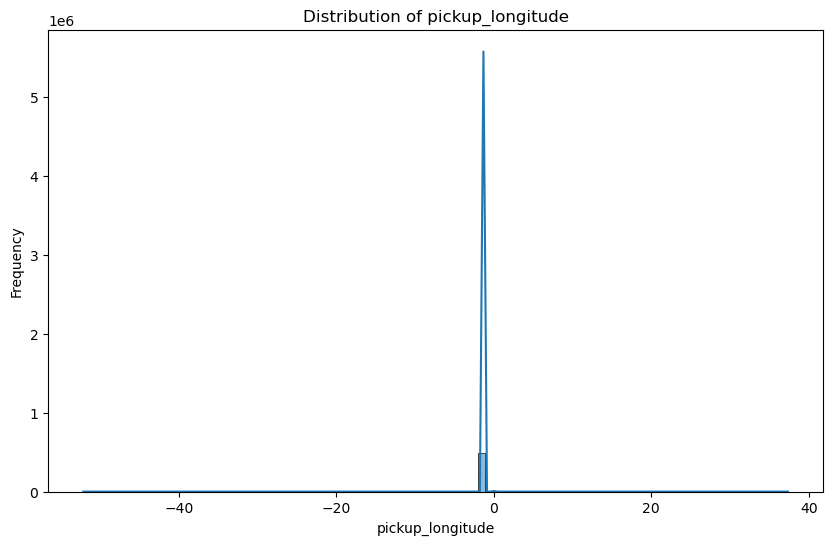

Skewness of pickup_longitude: -14.00771611481924


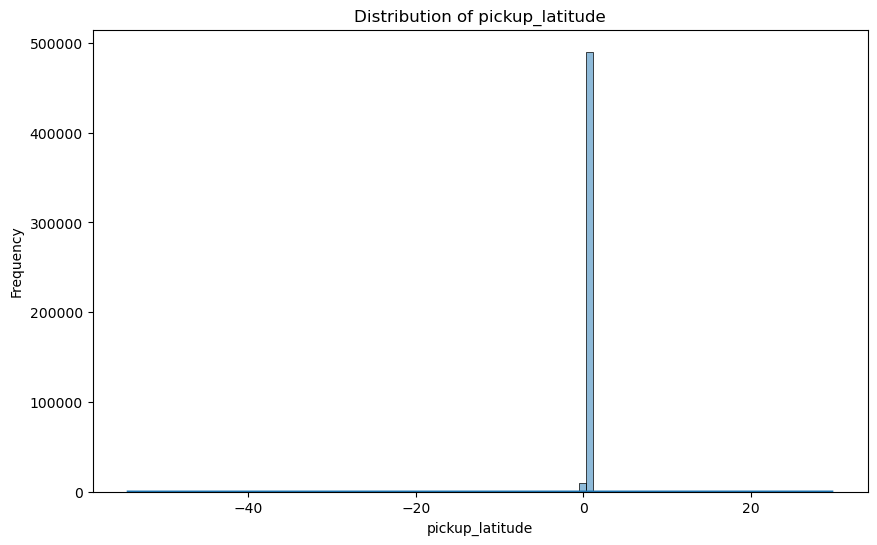

Skewness of pickup_latitude: -108.10101892253297


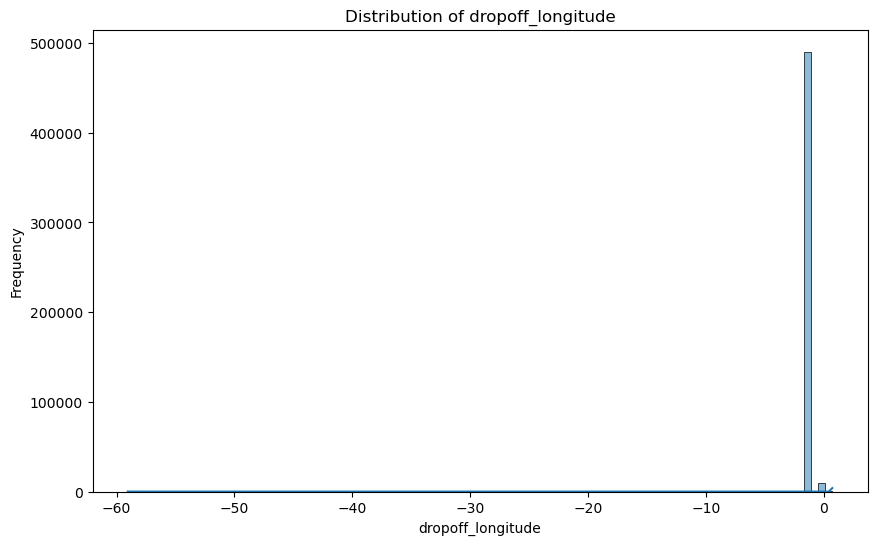

Skewness of dropoff_longitude: -44.81941402475158


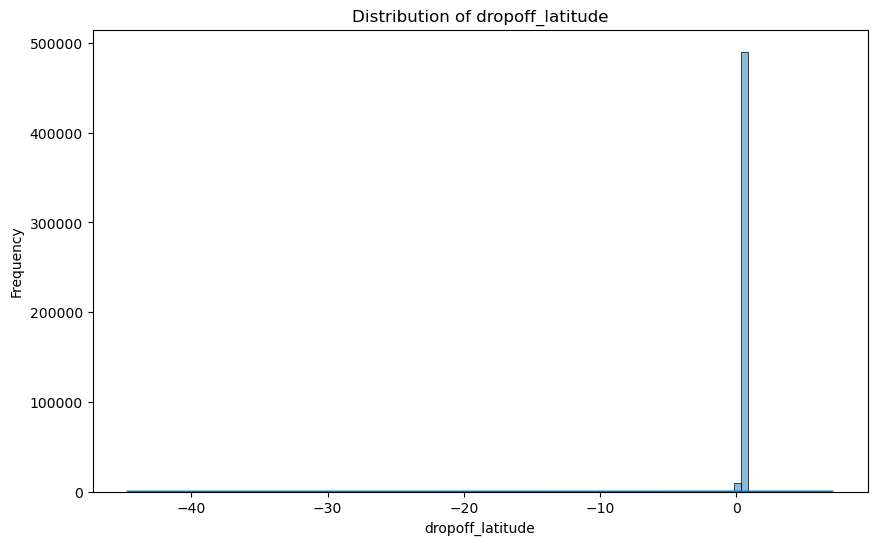

Skewness of dropoff_latitude: -100.30690763132287


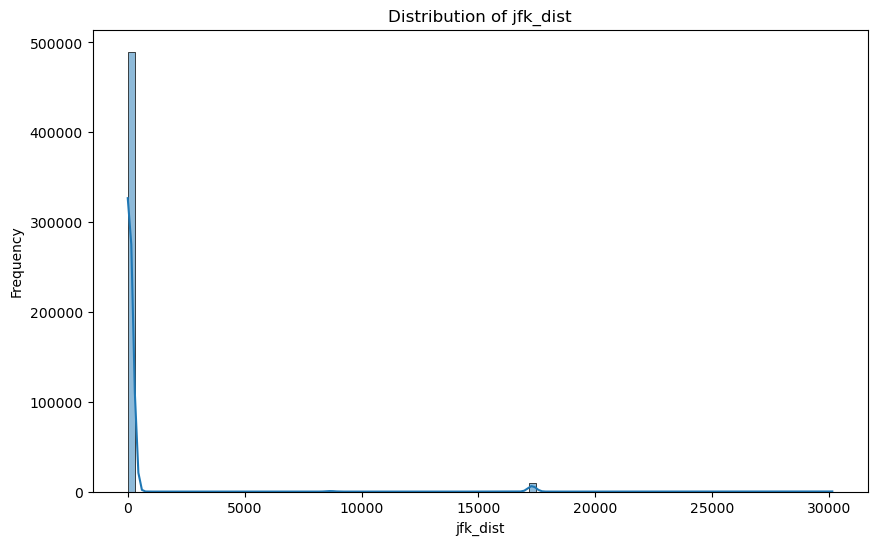

Skewness of jfk_dist: 7.167929098663729


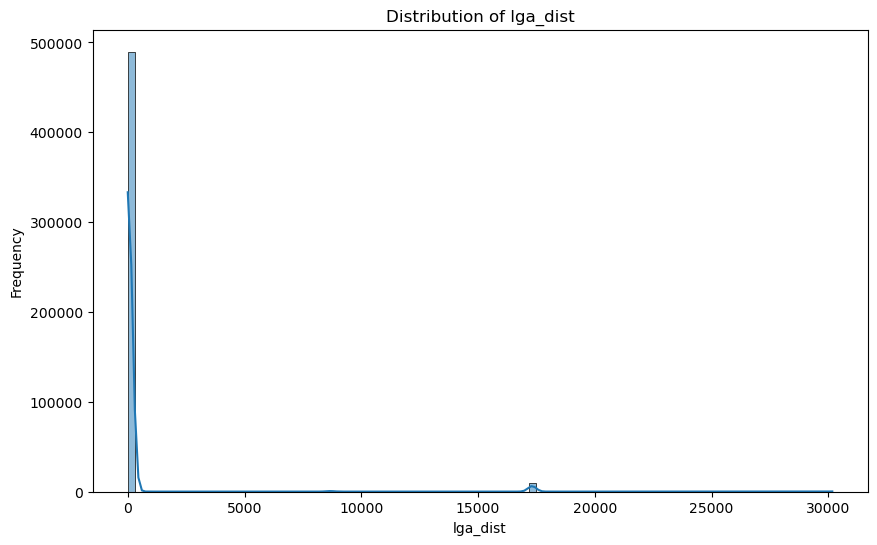

Skewness of lga_dist: 7.167155376154969


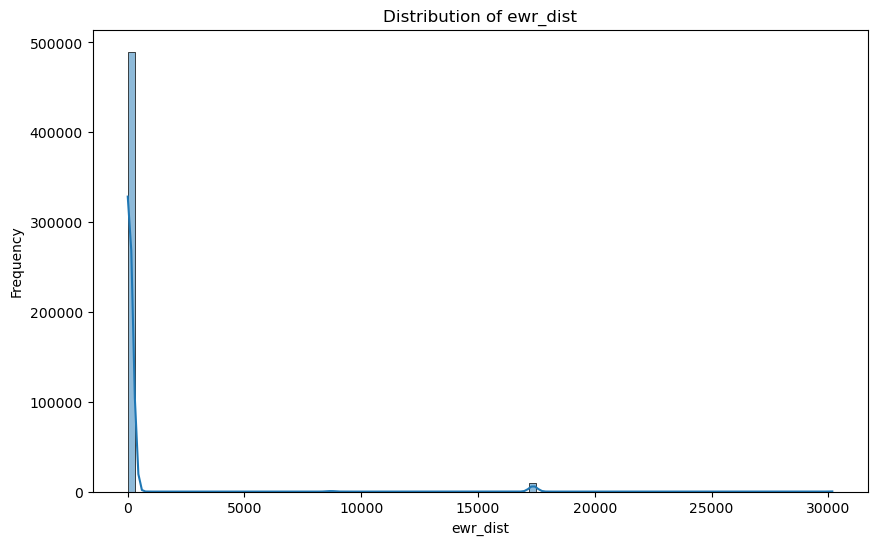

Skewness of ewr_dist: 7.164581656471356


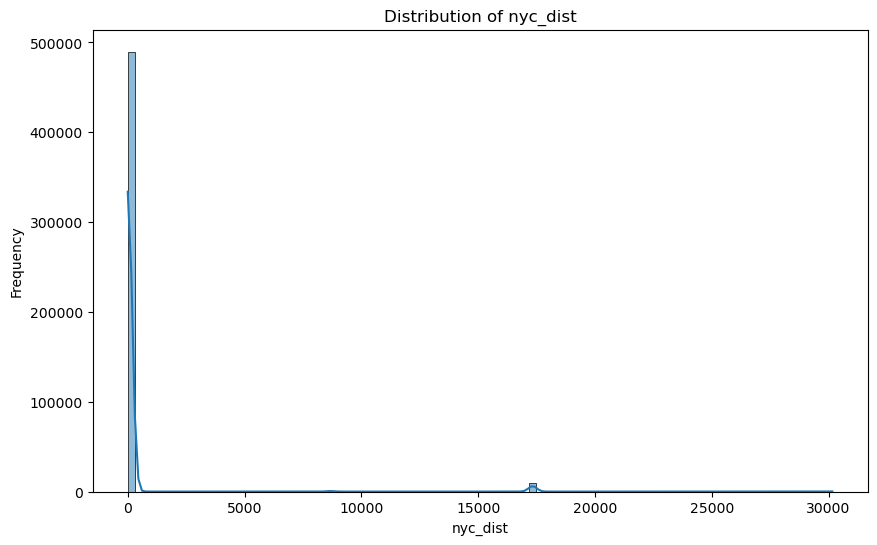

Skewness of nyc_dist: 7.165368173851034


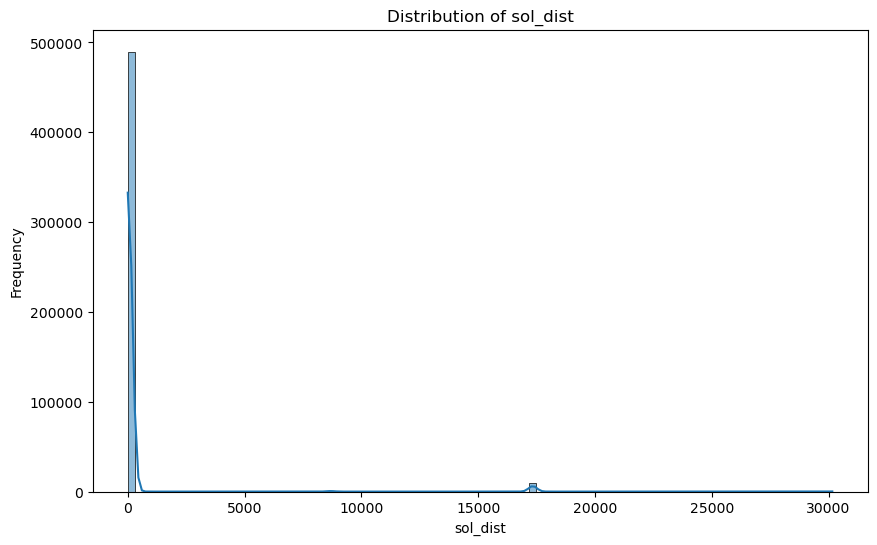

Skewness of sol_dist: 7.165138545508983


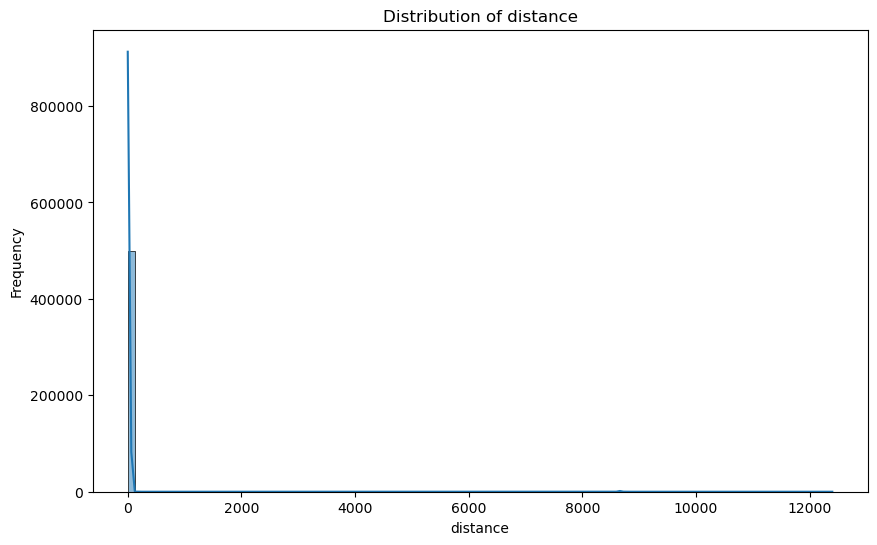

Skewness of distance: 22.987799827724483


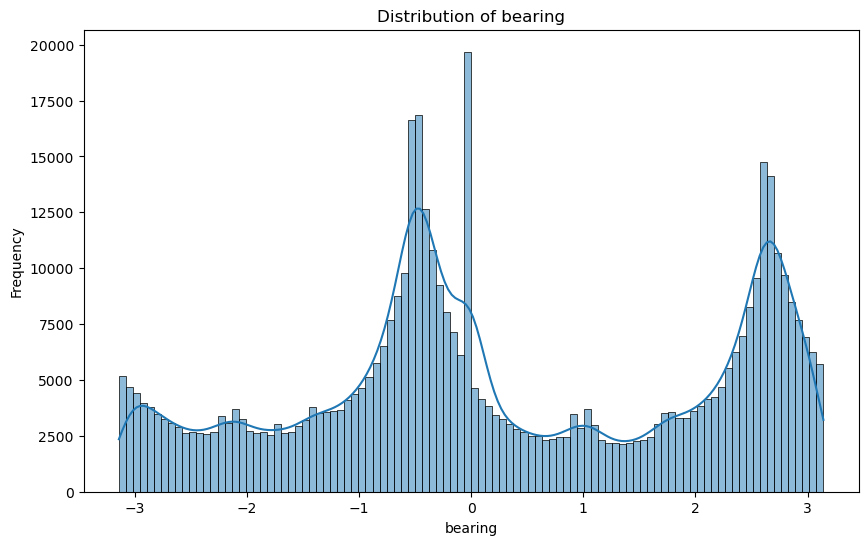

Skewness of bearing: -0.021611216042610383


In [271]:
numerical = ['fare_amount', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'jfk_dist', 'lga_dist', 'ewr_dist', 'nyc_dist', 'sol_dist', 'distance', 'bearing']

for feature in numerical:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[feature], bins=100, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()
    print(f"Skewness of {feature}: {df[feature].skew()}")


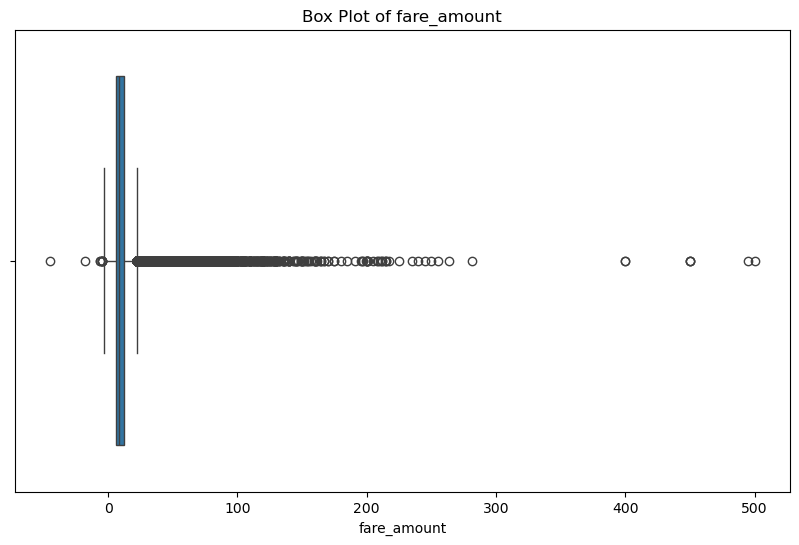

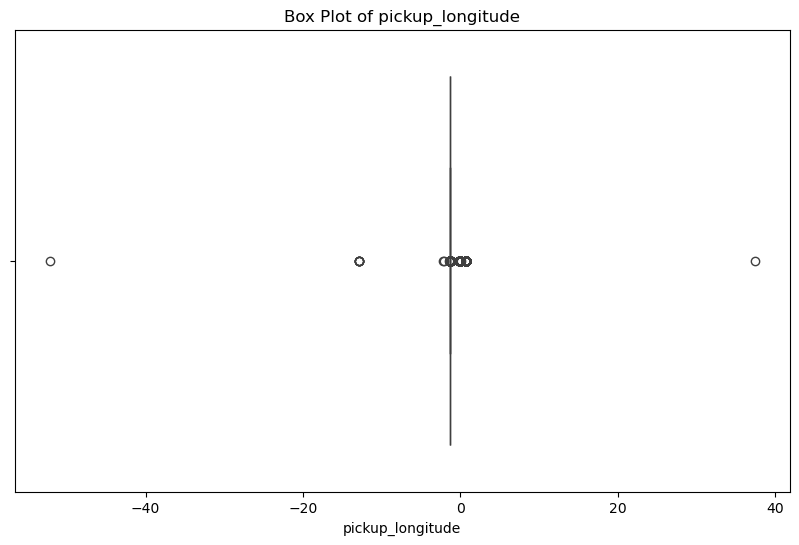

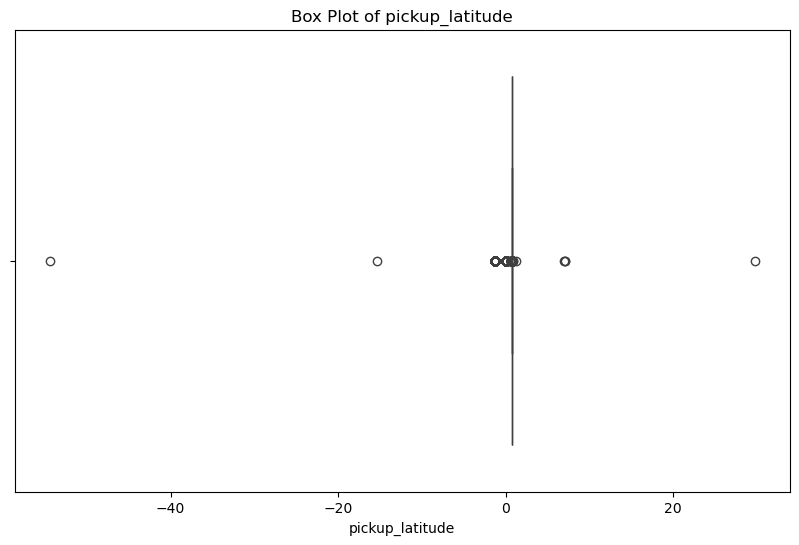

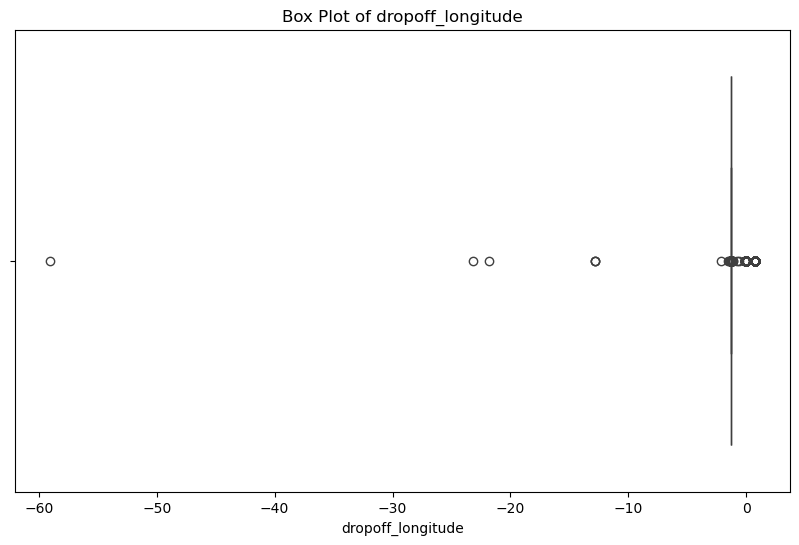

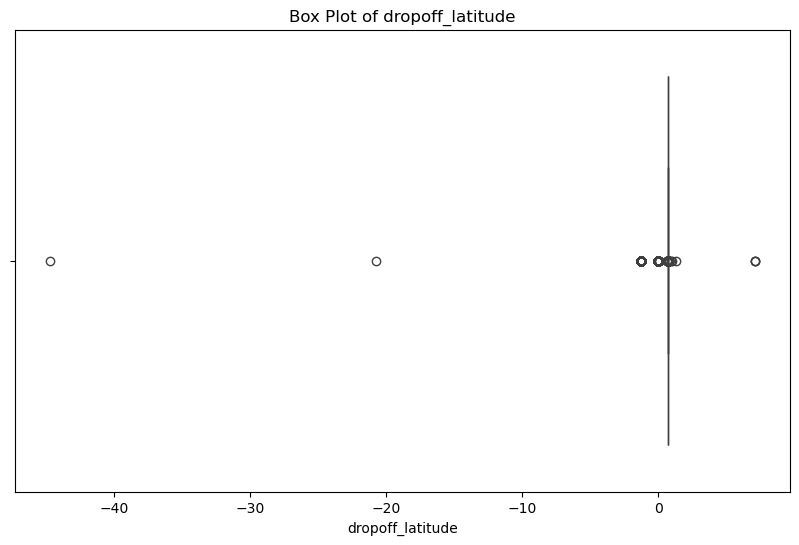

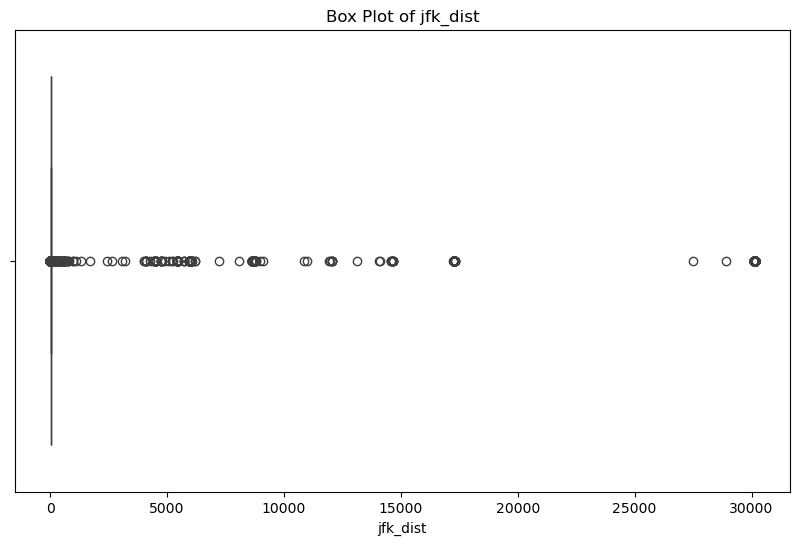

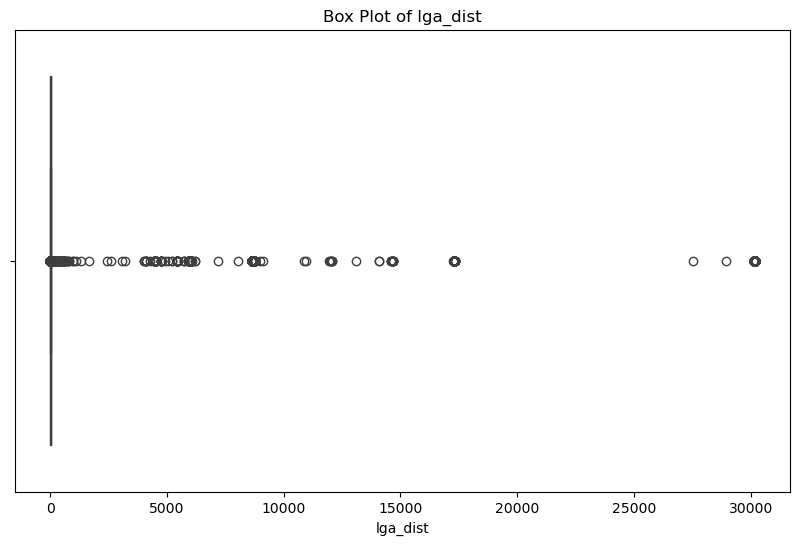

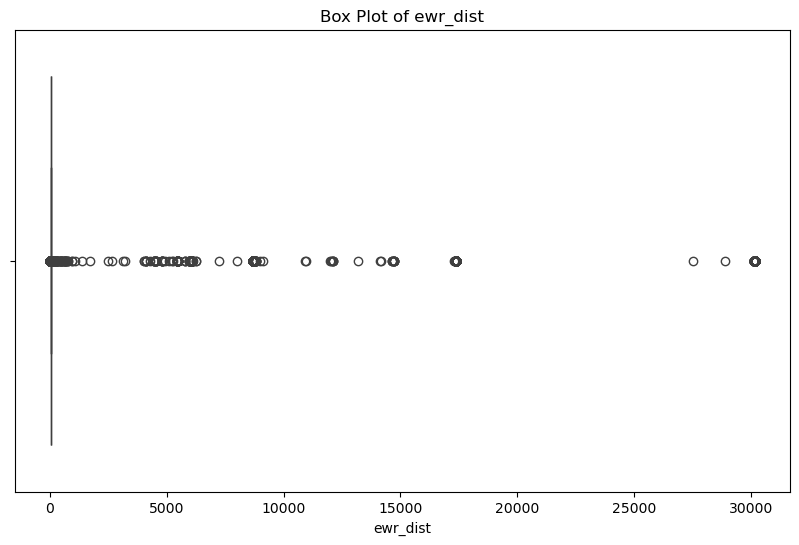

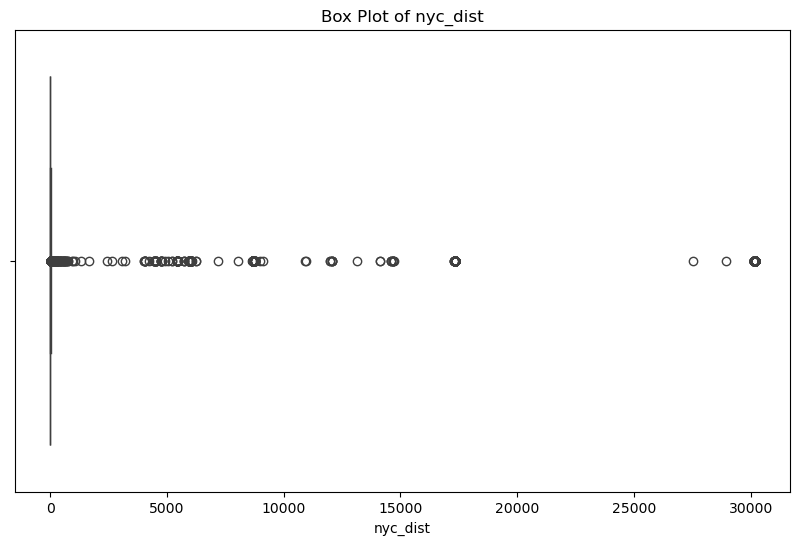

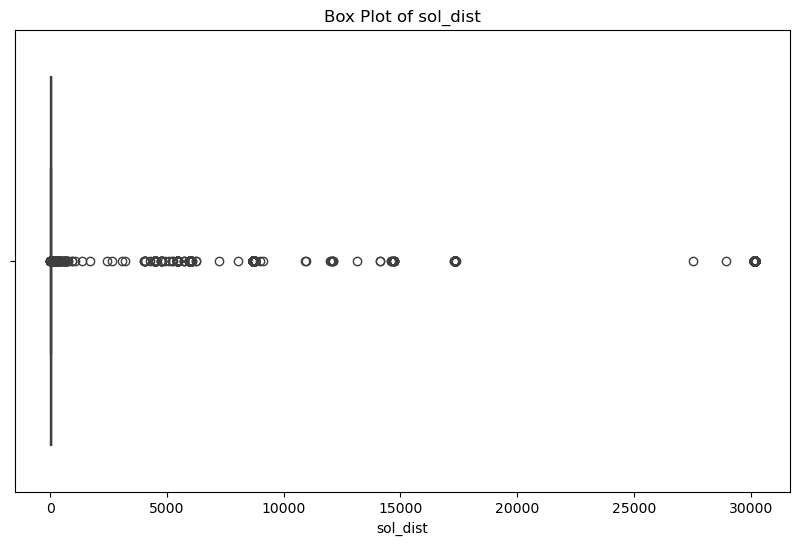

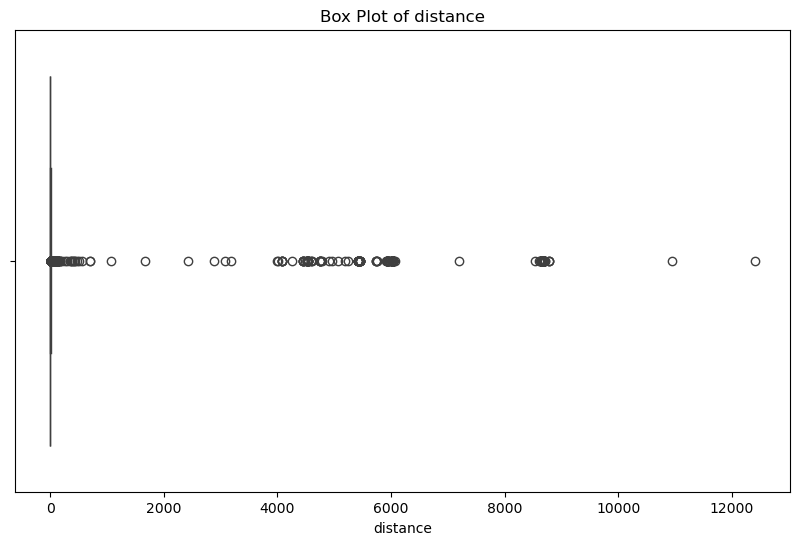

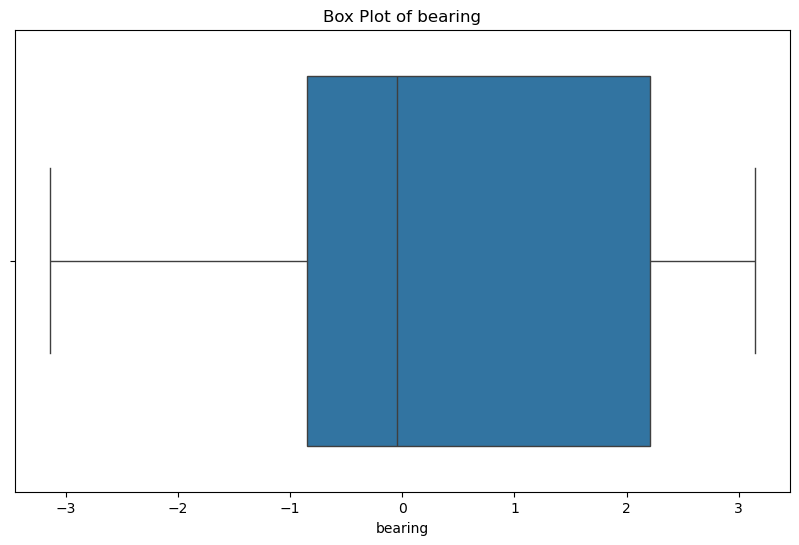

In [272]:
for feature in numerical:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.xlabel(feature)
    plt.show()

Negative fare amount ??

In [273]:
df[df['fare_amount'] < 0].head()

,Car Condition,Weather,Traffic Condition,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
2039,Good,stormy,Congested Traffic,-2.9,-1.287869,0.709363,-1.287855,0.709336,1.0,23,...,3,1,2010,1.846366,64.974364,33.066859,44.312412,39.949645,0.184225,-2.773833
2486,Bad,windy,Flow Traffic,-2.5,-1.291544,0.710709,-1.291540,0.710707,1.0,5,...,3,6,2015,41.388169,29.116540,24.876702,10.256816,1.796301,0.021244,-2.070541
13032,Bad,sunny,Congested Traffic,-3.0,-1.291457,0.711060,-1.291472,0.711071,4.0,8,...,8,4,2013,42.914915,31.117678,22.206688,14.187900,6.257058,0.096377,0.802983
28839,Bad,cloudy,Flow Traffic,-2.5,-1.287796,0.709449,0.000000,0.000000,1.0,13,...,8,6,2013,8647.851804,8712.832389,8673.451955,8692.106100,8687.155886,8647.451783,-1.758013
36722,Bad,sunny,Congested Traffic,-2.5,-1.290709,0.711922,-1.290672,0.711969,1.0,15,...,4,3,2015,44.517918,42.749523,13.596505,27.657482,19.552471,0.352924,-0.536786


In [274]:
(df['fare_amount'] < 0).sum()

21

Subsitute the negative with positive fare

In [275]:
df.loc[df['fare_amount'] < 0, 'fare_amount'] *= -1
(df['fare_amount'] < 0).sum()

0

We may need to apply log transform to skewed numerical features

In [276]:
skewness = df[numerical].skew()
print(skewness)

fare_amount            4.899668
pickup_longitude     -14.007716
pickup_latitude     -108.101019
dropoff_longitude    -44.819414
dropoff_latitude    -100.306908
jfk_dist               7.167929
lga_dist               7.167155
ewr_dist               7.164582
nyc_dist               7.165368
sol_dist               7.165139
distance              22.987800
bearing               -0.021611
dtype: float64


In [277]:
skewed_features = skewness[abs(skewness) > 1].index

# Apply log transform to skewed numerical features
df[skewed_features] = df[skewed_features].apply(lambda x: np.log1p(x))
df[numerical].skew()

c:\Users\mohdy\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


fare_amount           0.981228
pickup_longitude     10.909422
pickup_latitude      -6.815757
dropoff_longitude     4.816743
dropoff_latitude     -6.964078
jfk_dist              6.326436
lga_dist              6.201050
ewr_dist              6.495860
nyc_dist              4.930865
sol_dist              5.932095
distance              2.905397
bearing              -0.021611
dtype: float64

## Analysis with target

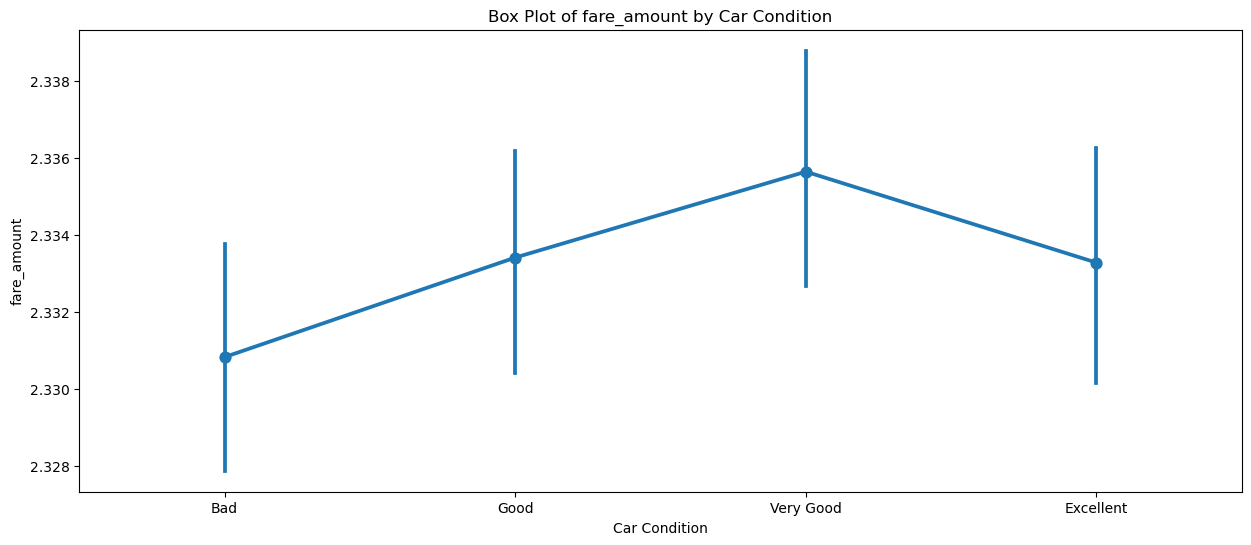

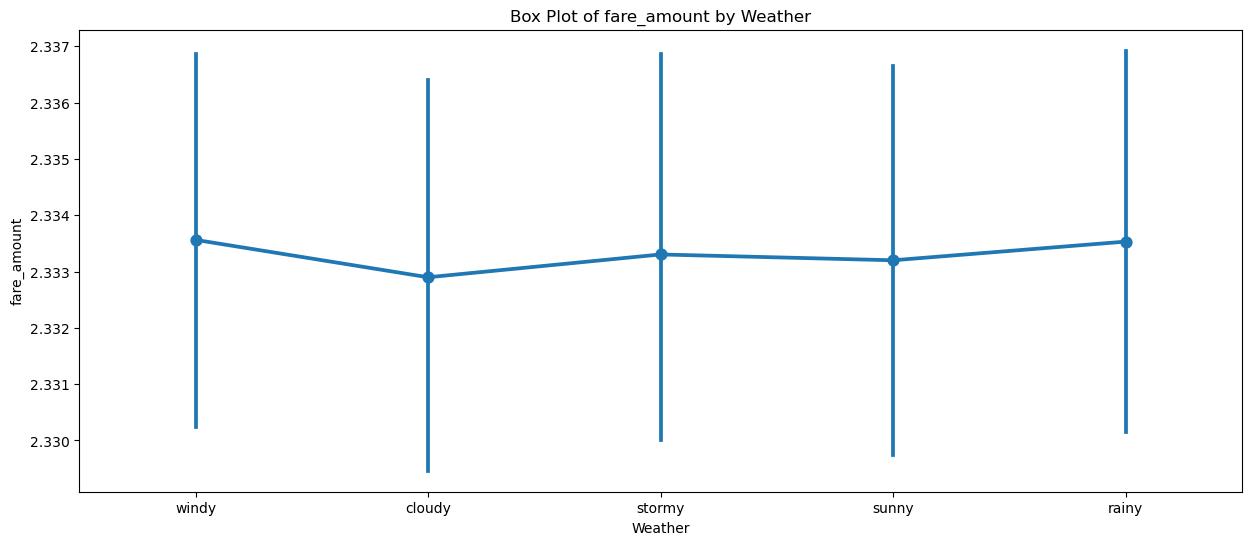

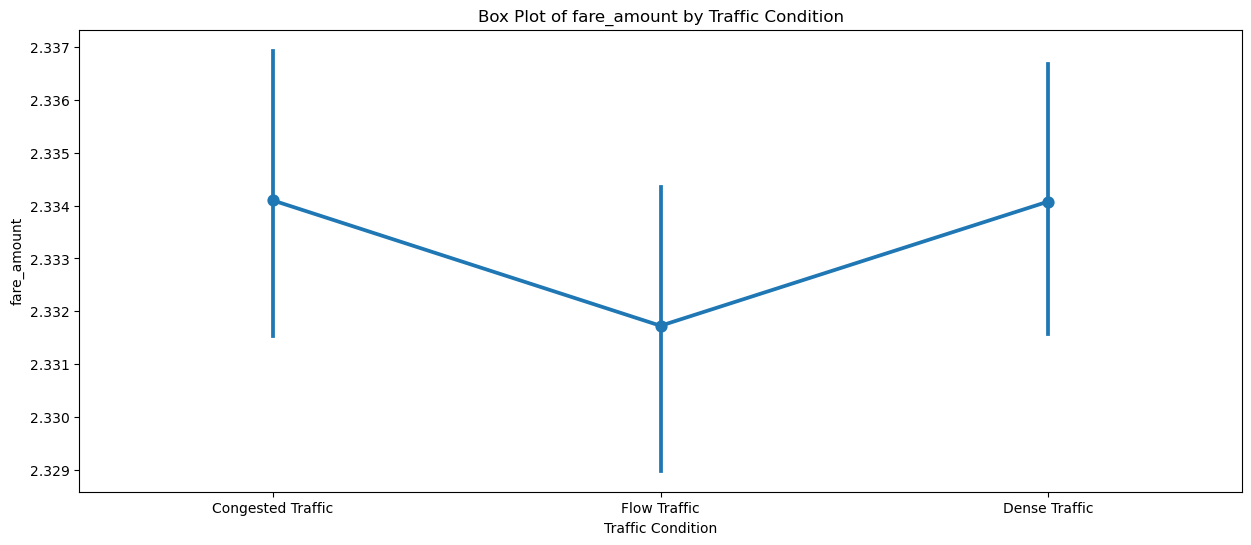

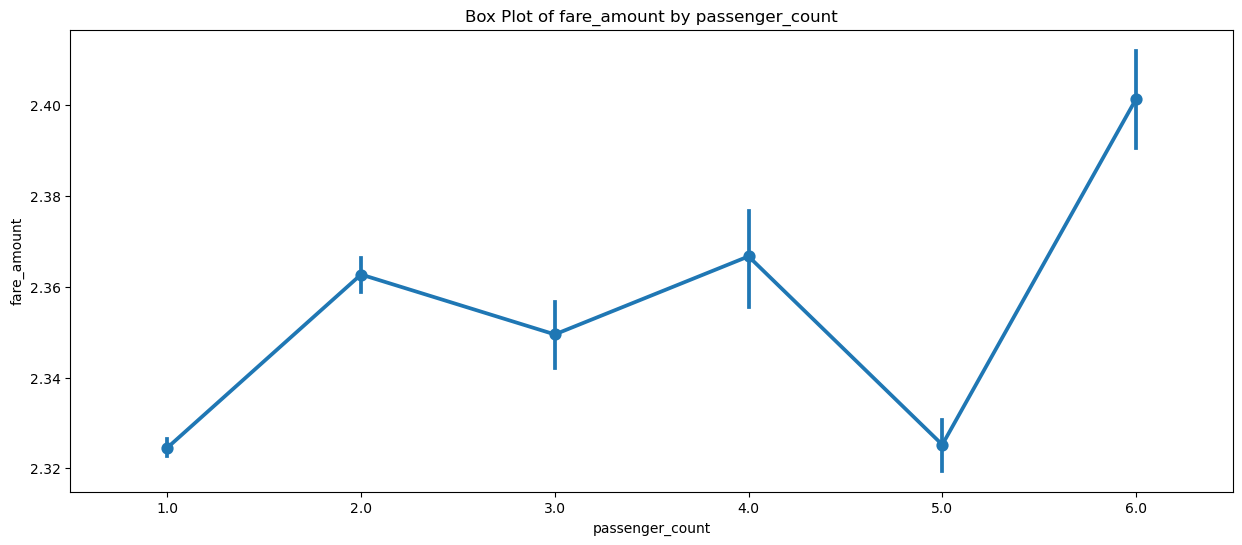

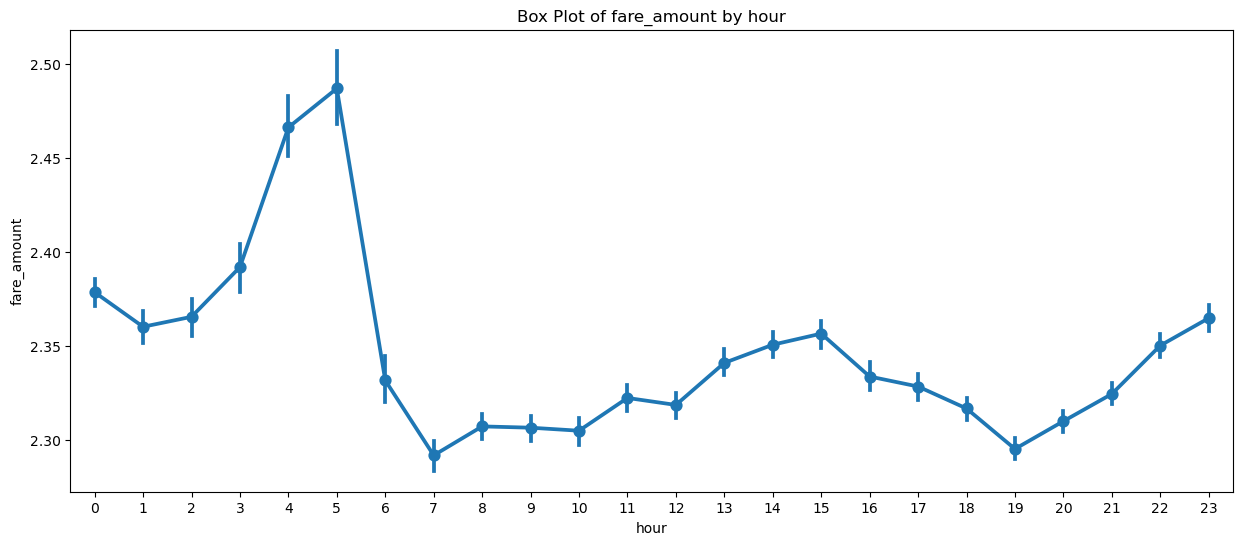

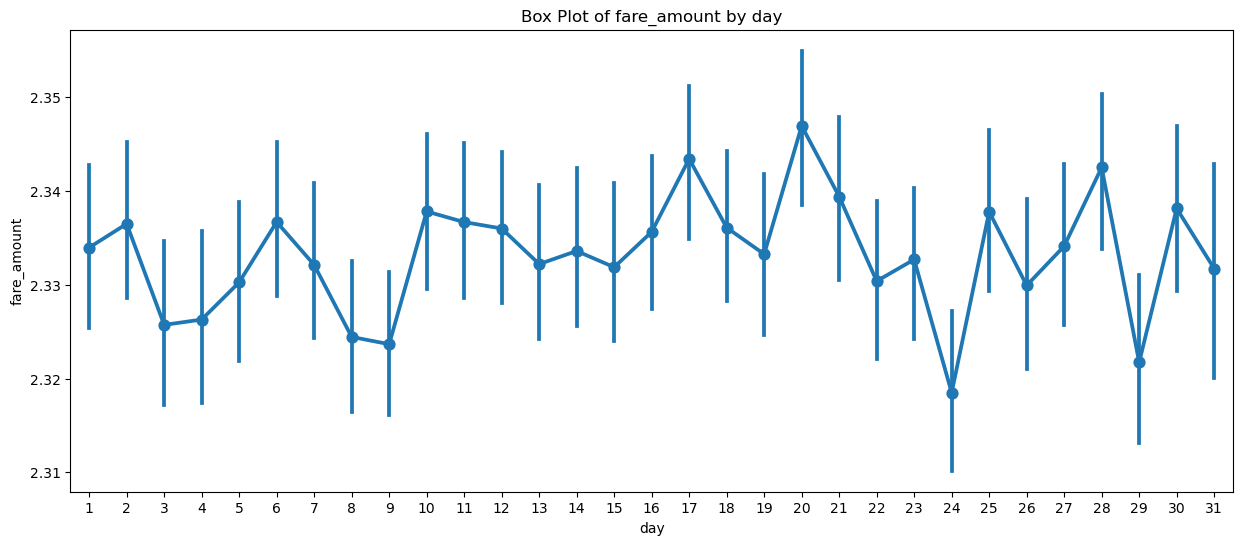

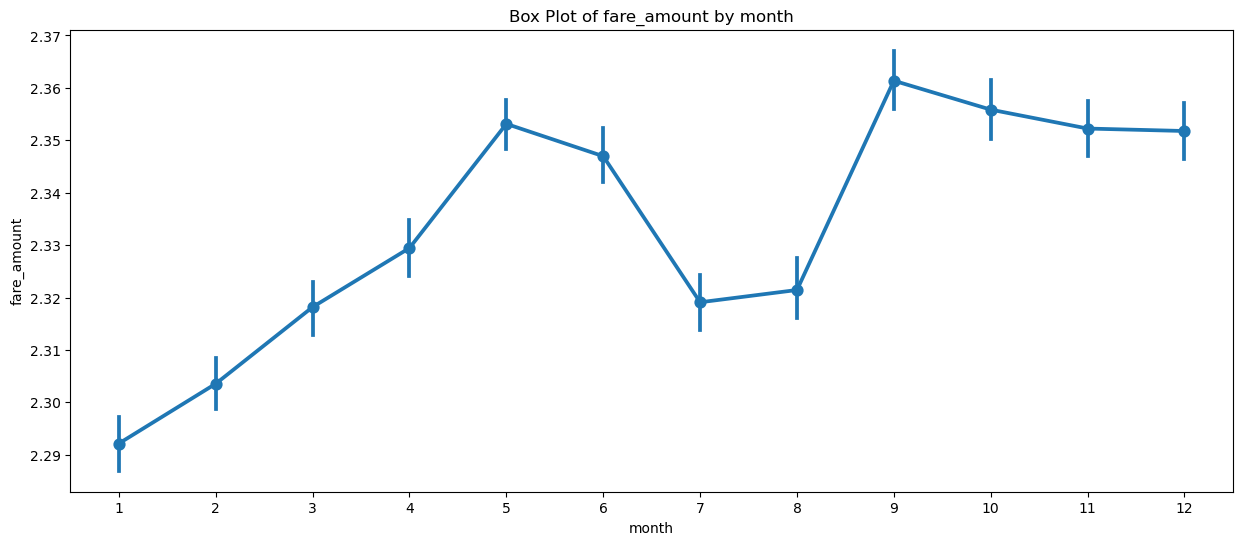

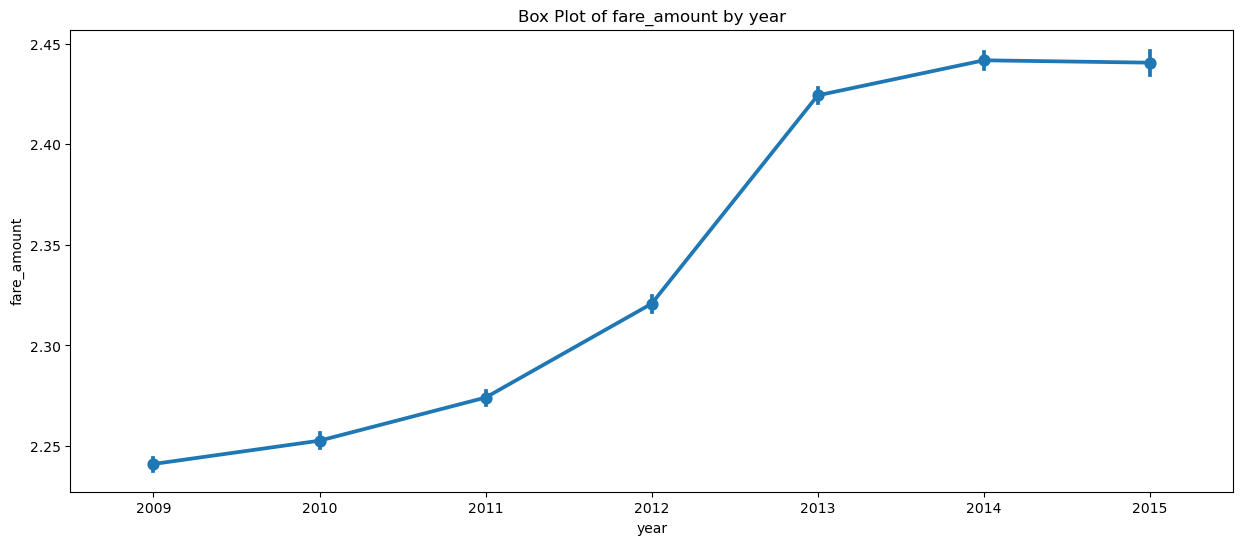

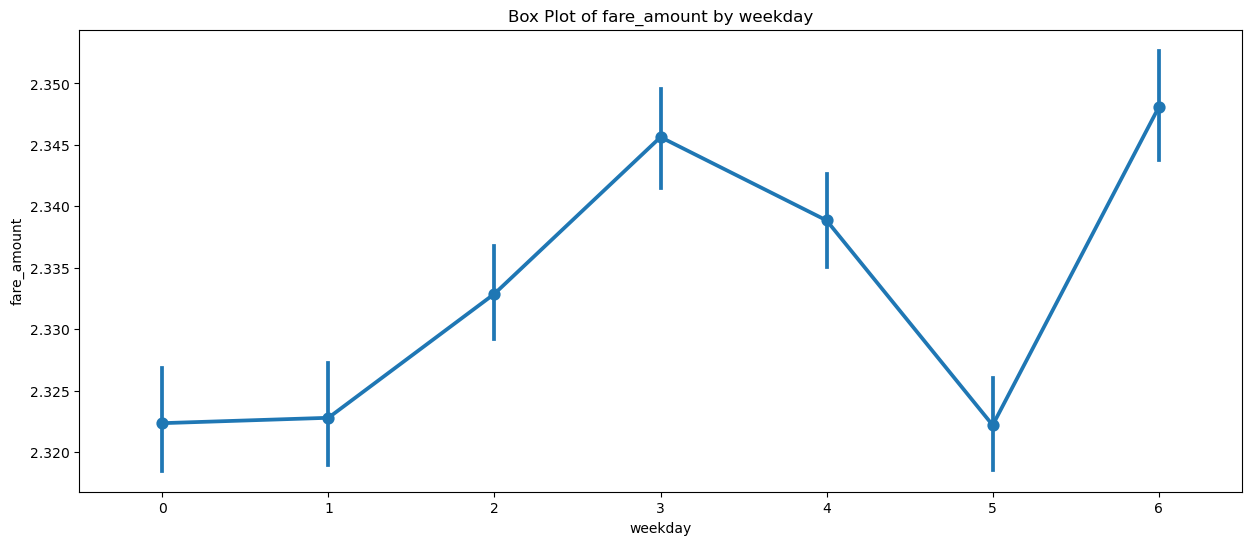

In [278]:
order_carCondition = ['Bad', 'Good', 'Very Good', 'Excellent']
for feature in categorical:
    if feature == 'Car Condition':
        order=order_carCondition
    else:
        order=None
    plt.figure(figsize=(15, 6))
    sns.pointplot(x=feature, y='fare_amount', data=df, order=order)
    plt.xlabel(f'{feature}')
    plt.ylabel('fare_amount')
    plt.title(f'Box Plot of fare_amount by {feature}')
    plt.show()

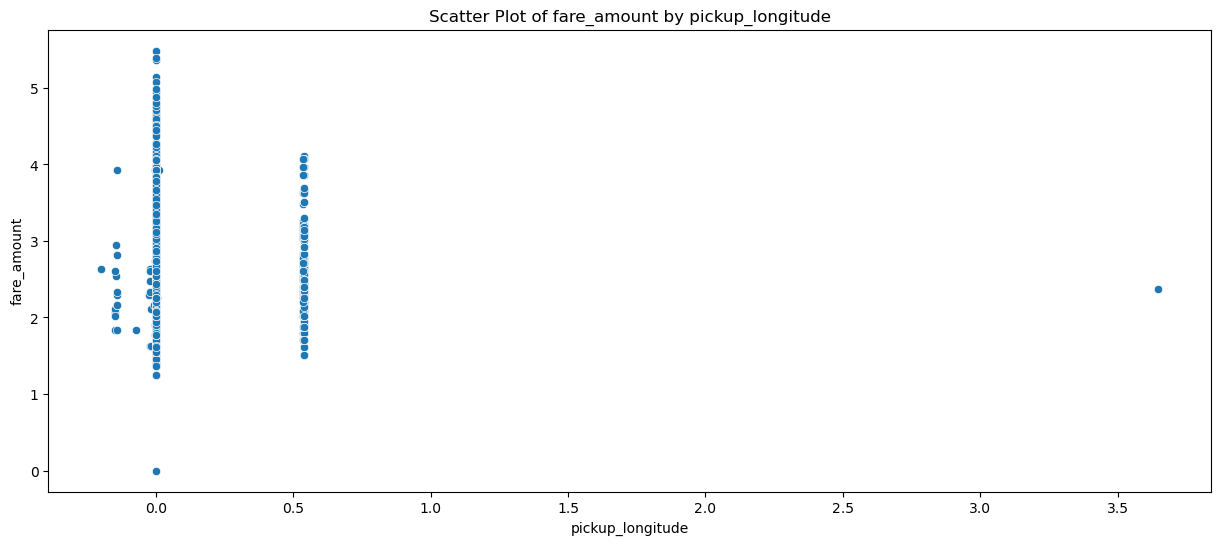

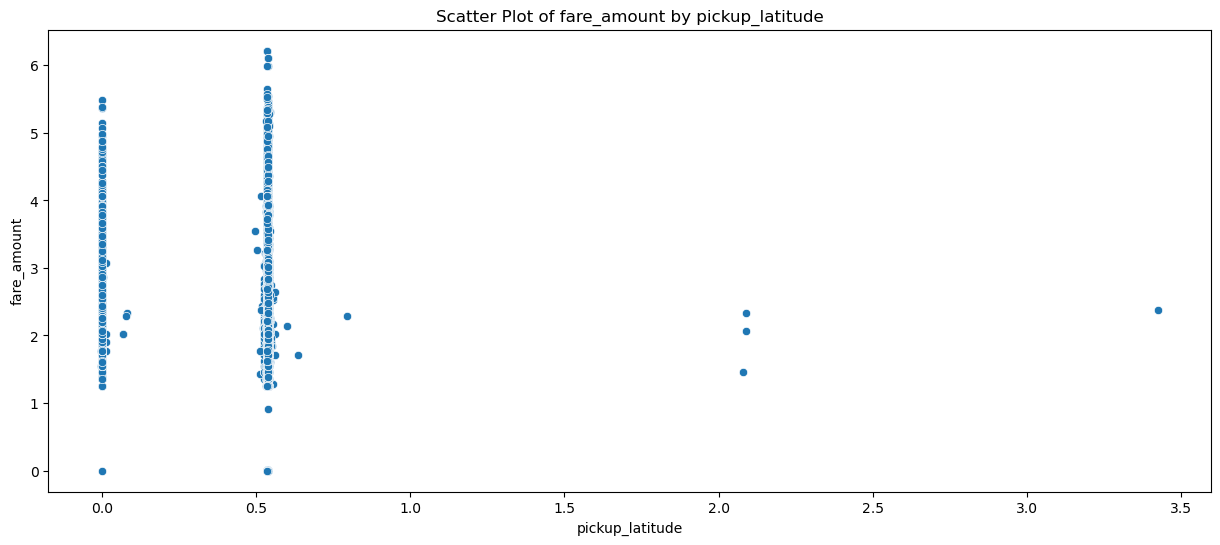

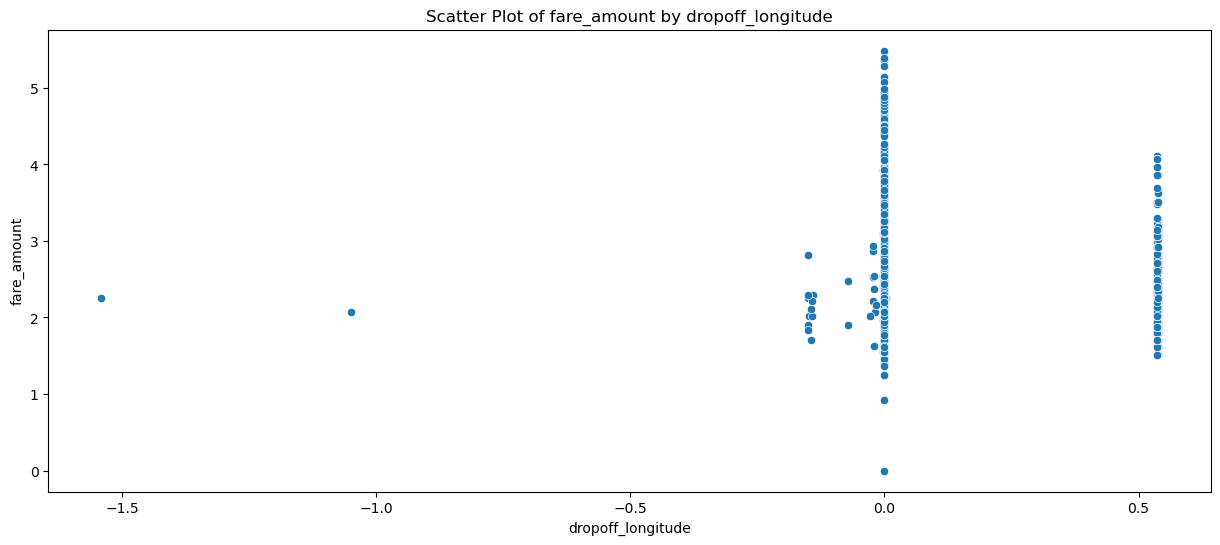

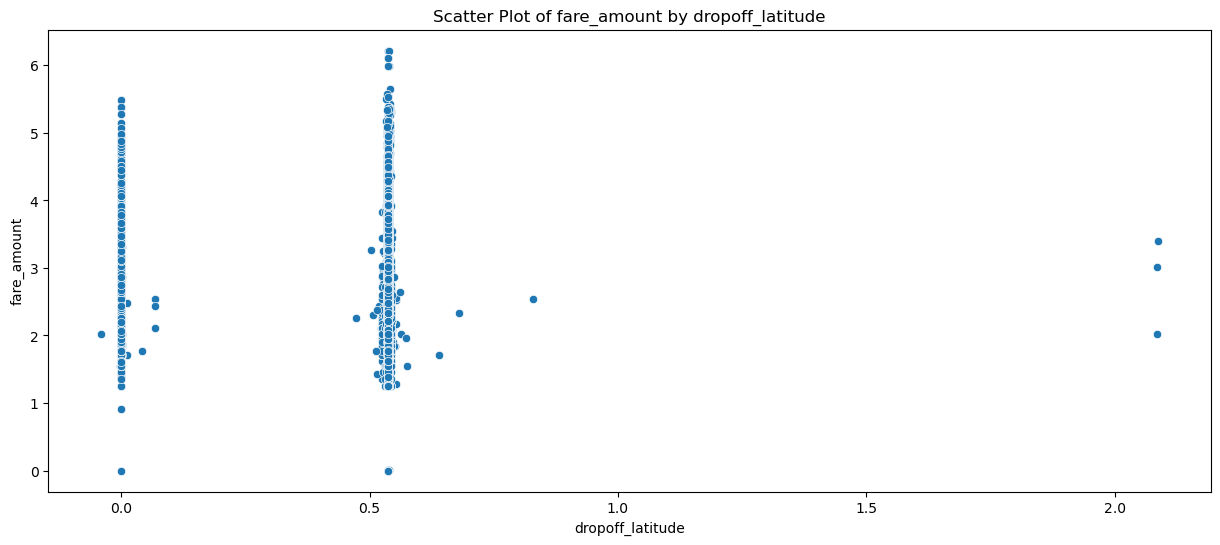

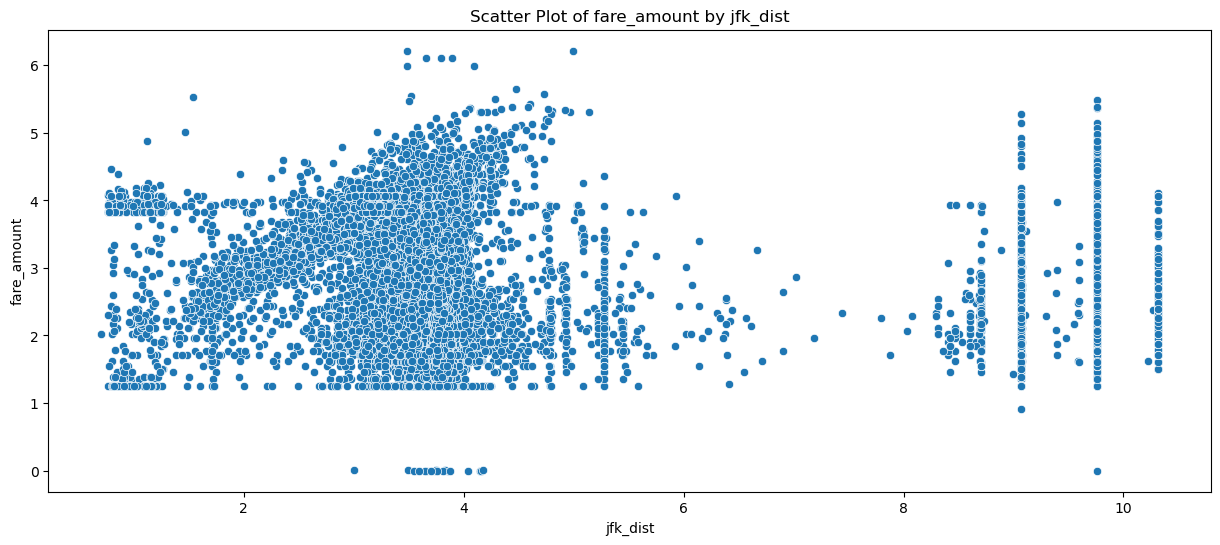

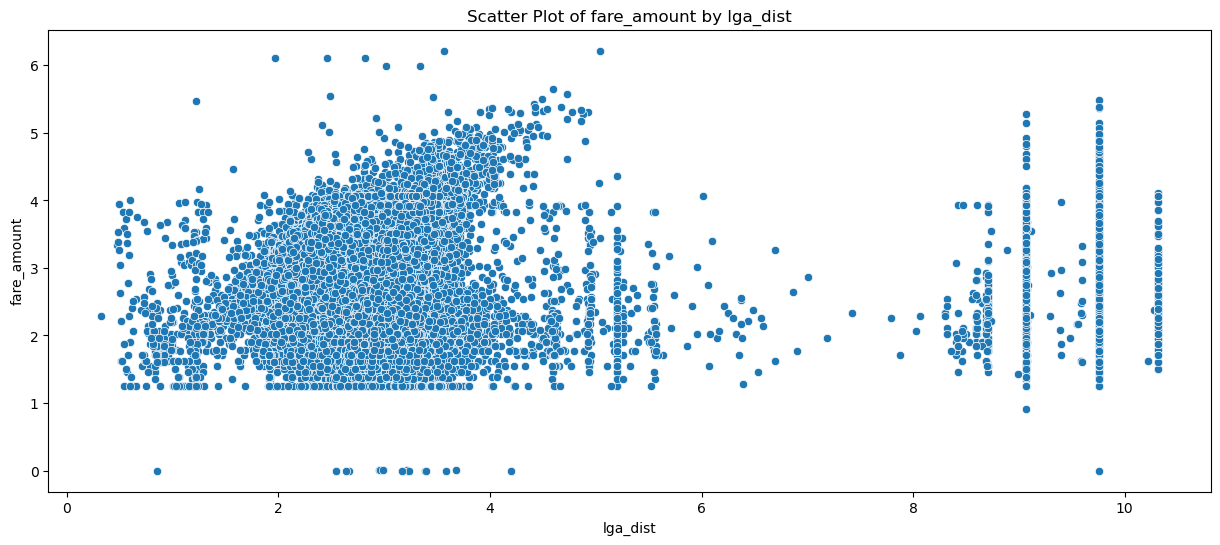

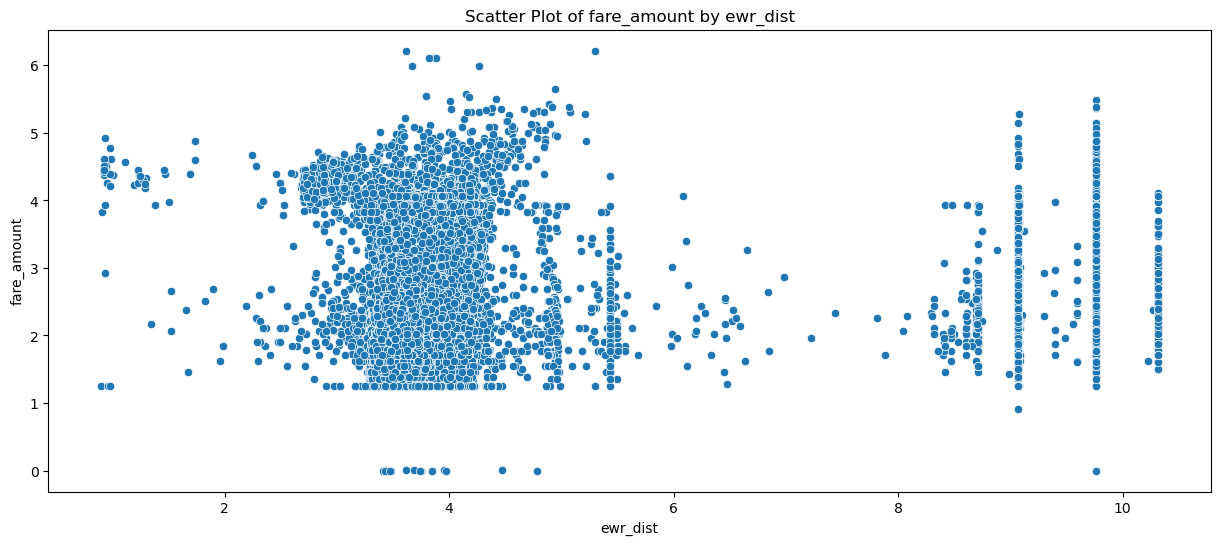

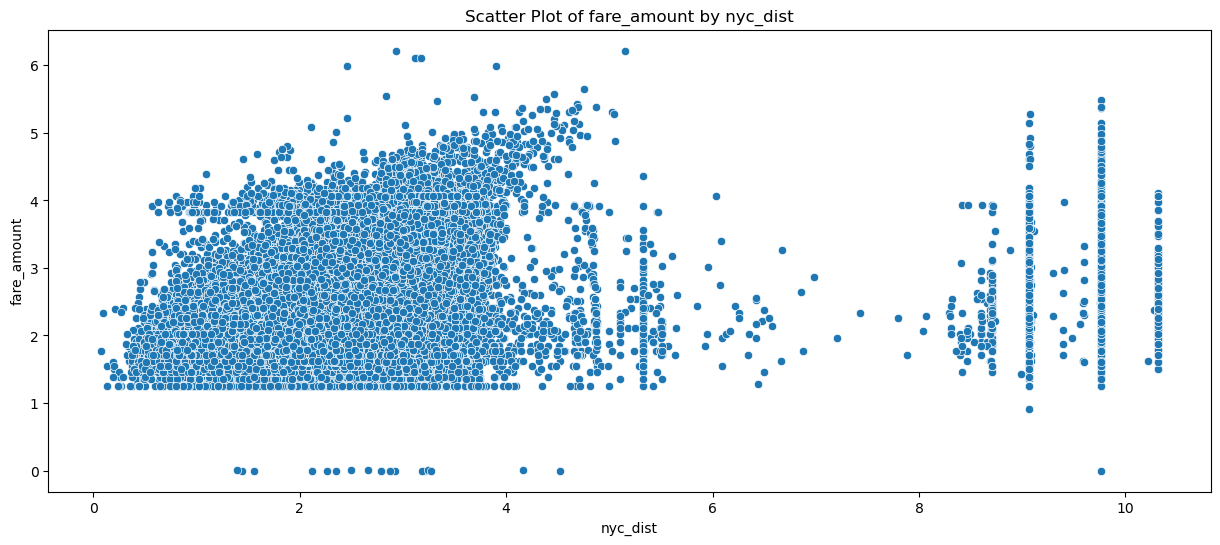

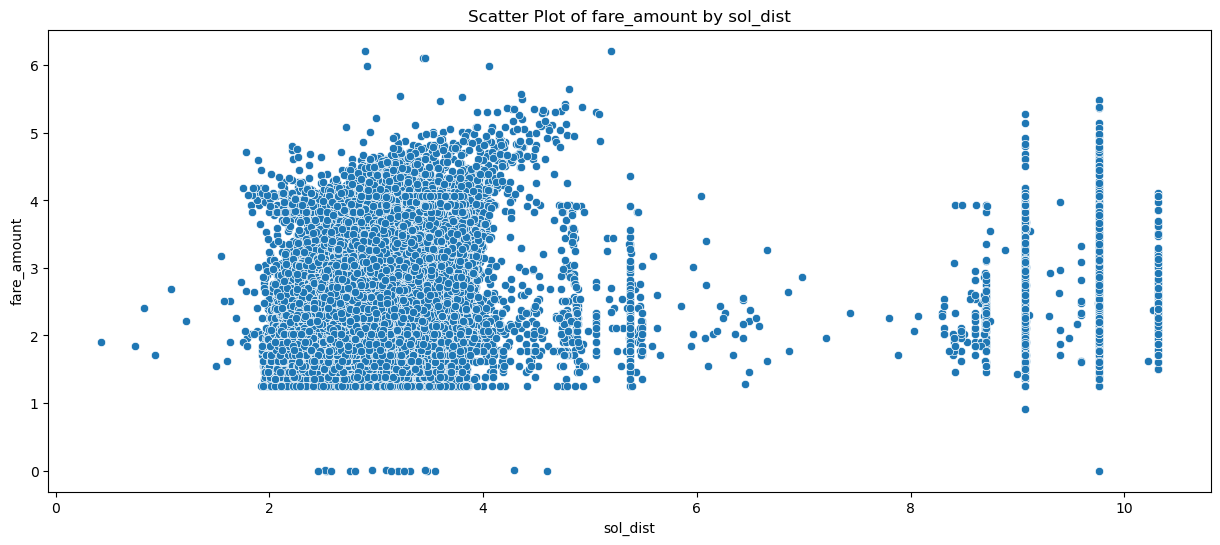

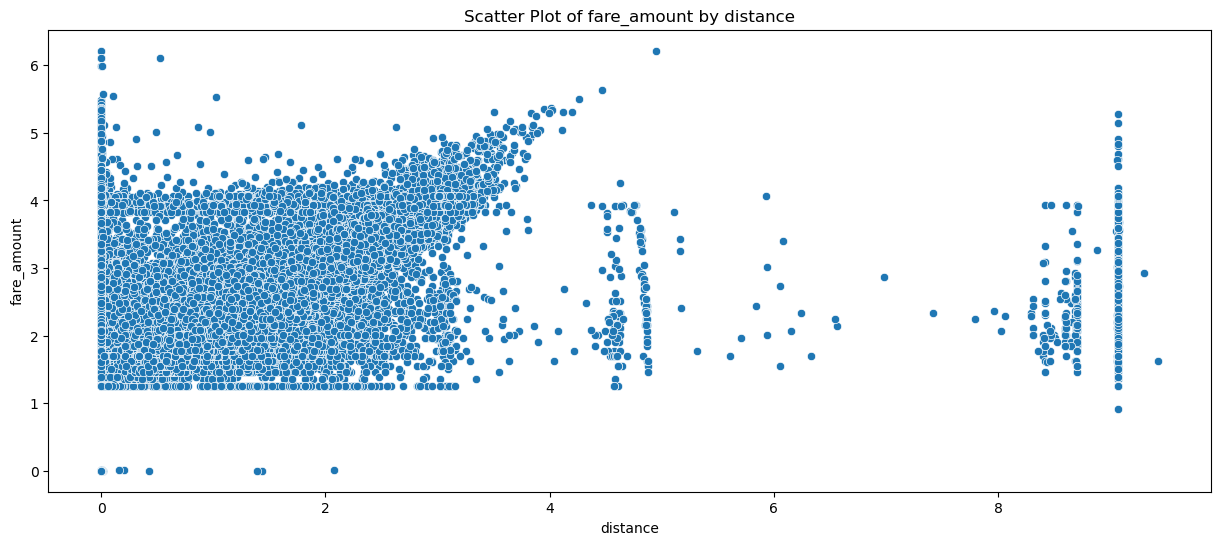

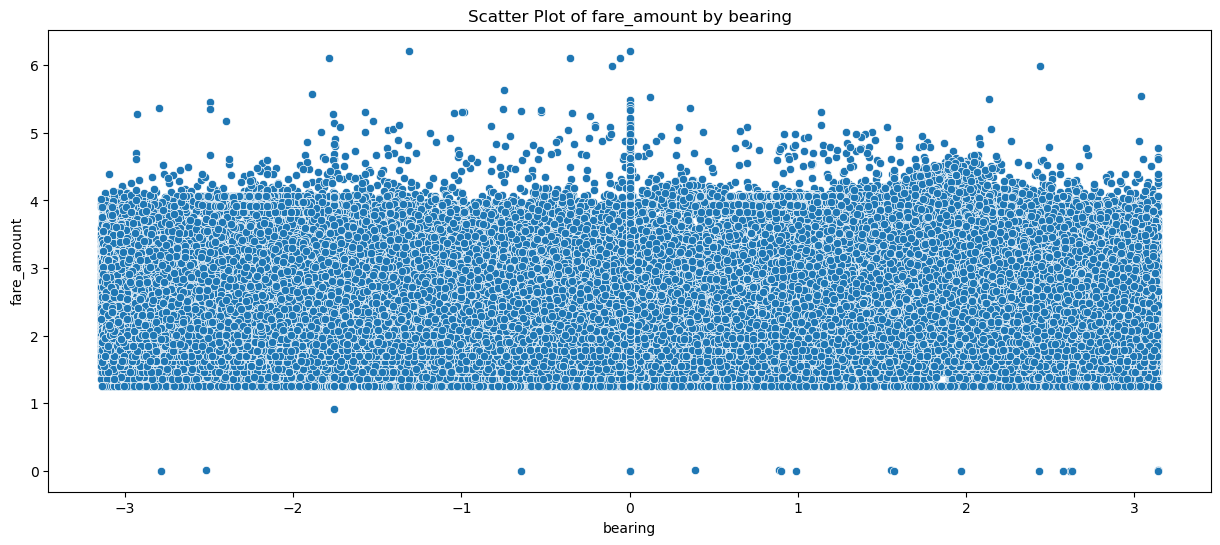

In [279]:
for feature in numerical:
    if feature == 'fare_amount':
        continue
    plt.figure(figsize=(15, 6))
    sns.scatterplot(x=feature, y='fare_amount', data=df)
    plt.title(f'Scatter Plot of fare_amount by {feature}')
    plt.xlabel(feature)
    plt.ylabel('fare_amount')
    plt.show()

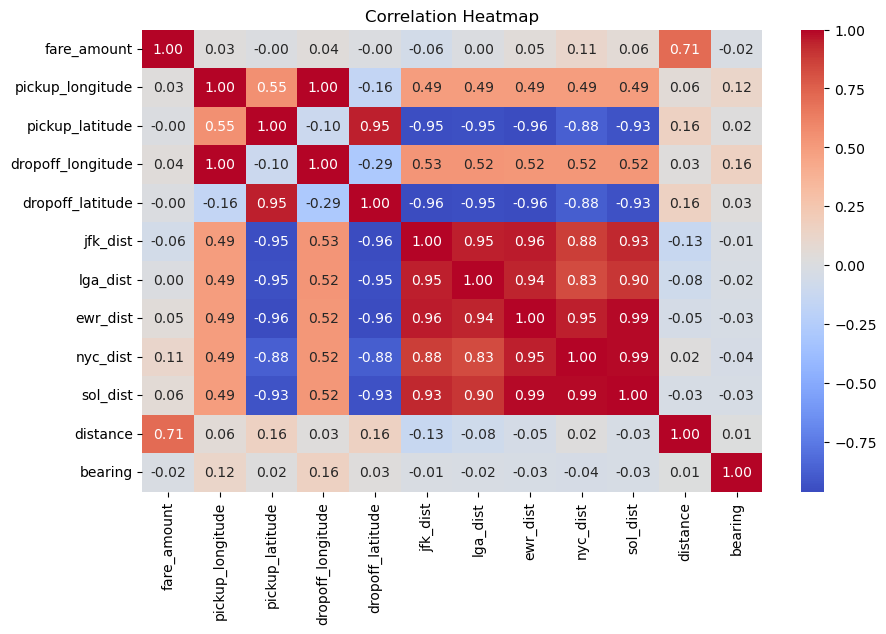

In [280]:
# Heatmap for correlation analysis
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

High Correlation with distance

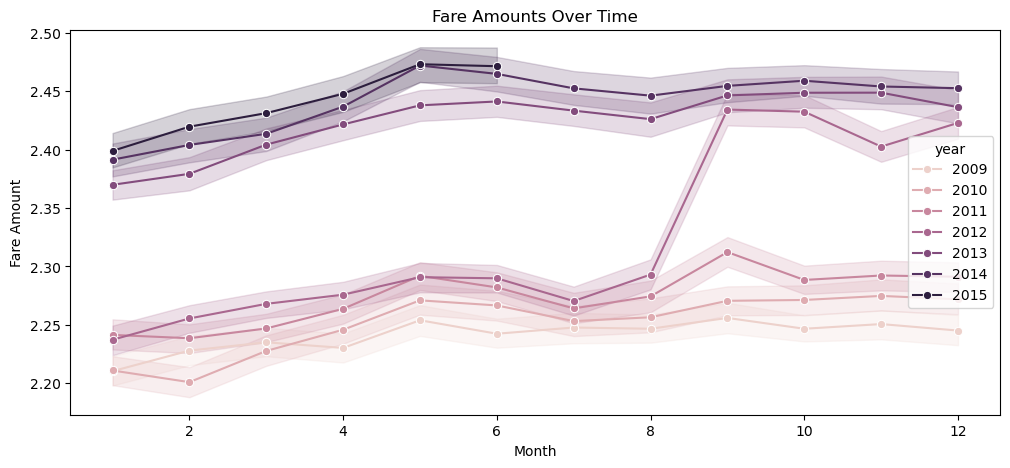

In [281]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="month", y="fare_amount", hue="year", marker="o")
plt.xlabel("Month")
plt.ylabel("Fare Amount")
plt.title("Fare Amounts Over Time")
plt.show()

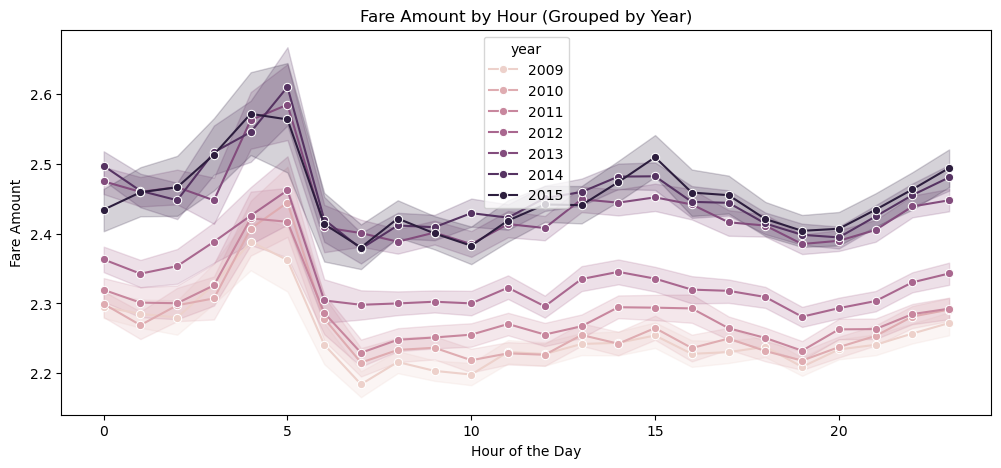

In [282]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="hour", y="fare_amount", hue="year", marker="o")
plt.xlabel("Hour of the Day")
plt.ylabel("Fare Amount")
plt.title("Fare Amount by Hour (Grouped by Year)")
plt.show()

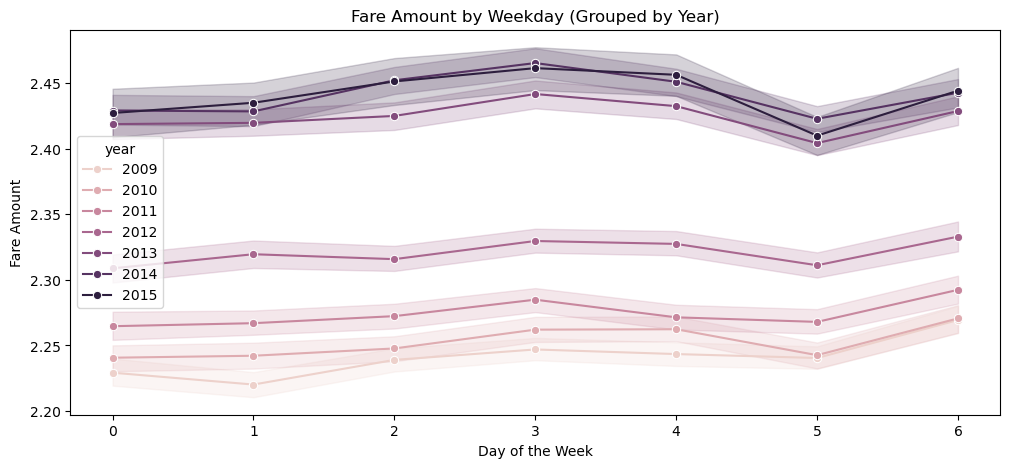

In [283]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="weekday", y="fare_amount", hue="year", marker="o")
plt.xlabel("Day of the Week")
plt.ylabel("Fare Amount")
plt.title("Fare Amount by Weekday (Grouped by Year)")
plt.show()

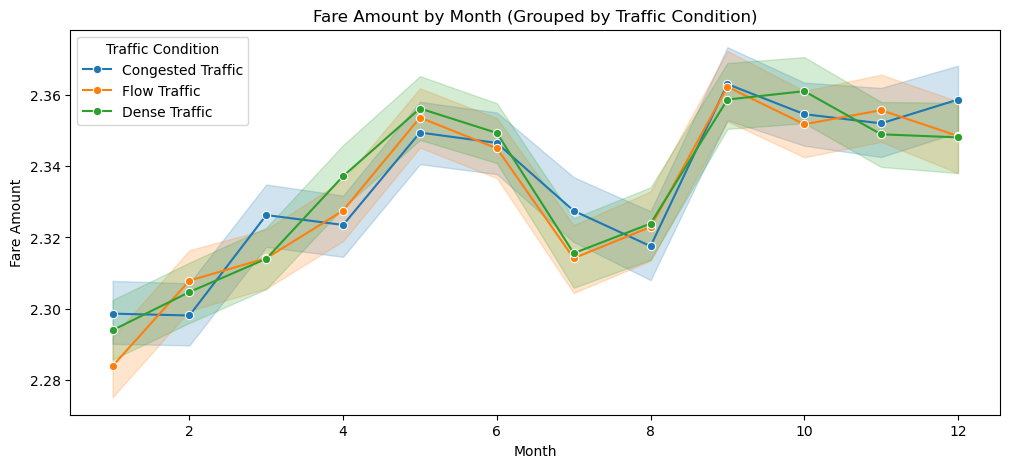

In [284]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="month", y="fare_amount", hue="Traffic Condition", marker="o")
plt.xlabel("Month")
plt.ylabel("Fare Amount")
plt.title("Fare Amount by Month (Grouped by Traffic Condition)")
plt.show()

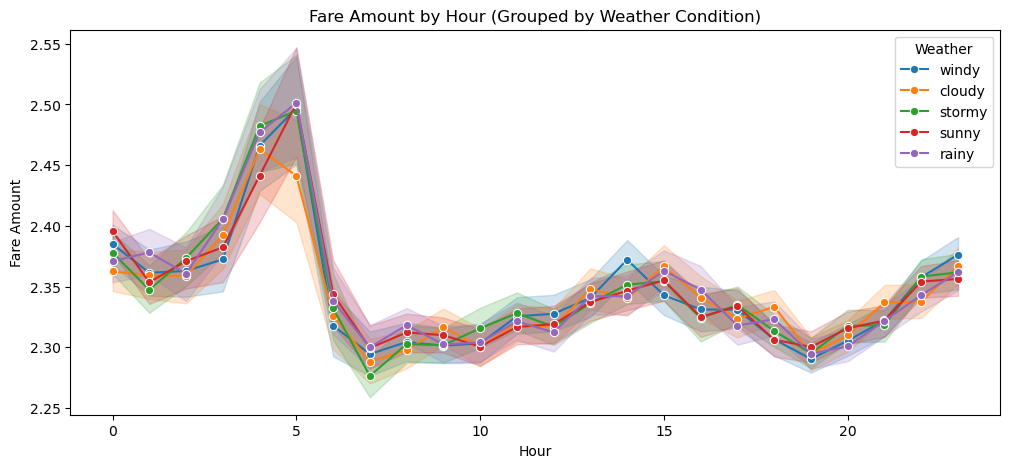

In [285]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="hour", y="fare_amount", hue="Weather", marker="o")
plt.xlabel("Hour")
plt.ylabel("Fare Amount")
plt.title("Fare Amount by Hour (Grouped by Weather Condition)")
plt.show()

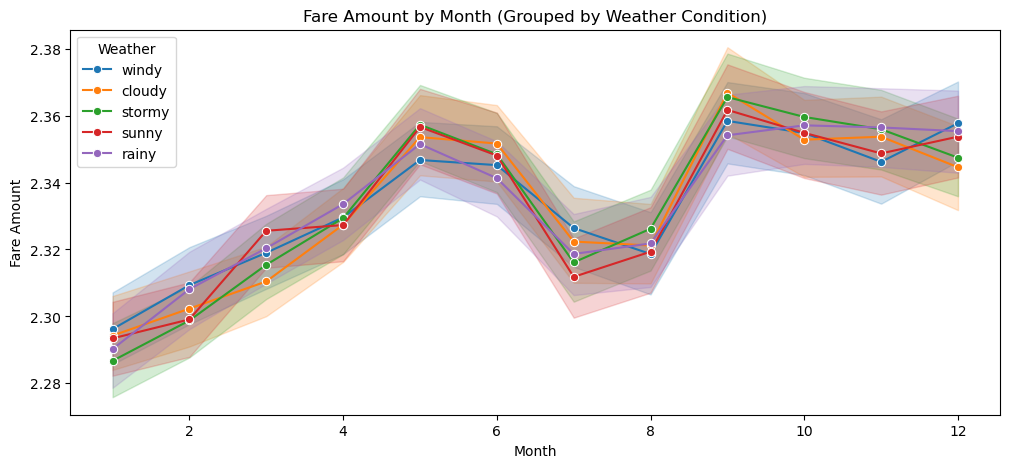

In [286]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="month", y="fare_amount", hue="Weather", marker="o")
plt.xlabel("Month")
plt.ylabel("Fare Amount")
plt.title("Fare Amount by Month (Grouped by Weather Condition)")
plt.show()

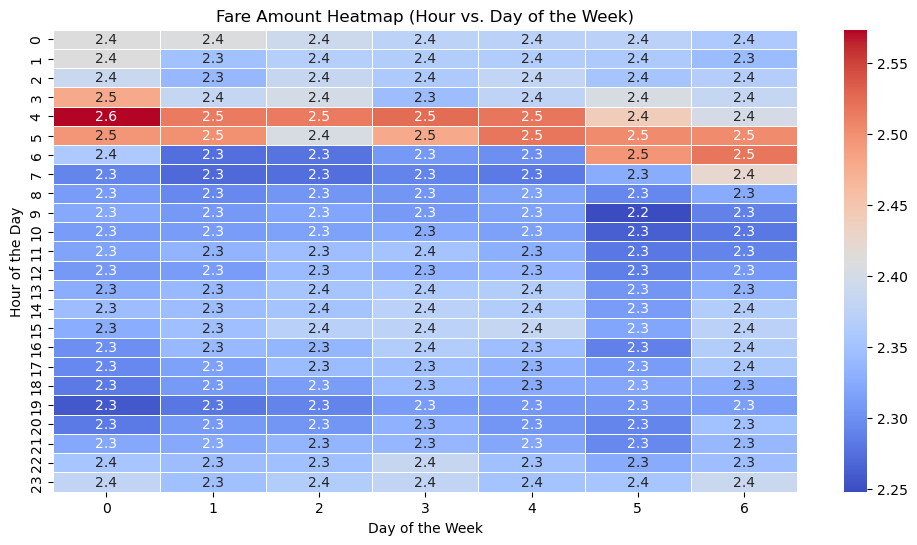

In [287]:
pivot_table = df.pivot_table(values='fare_amount', index='hour', columns='weekday', aggfunc='mean')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap="coolwarm", annot=True, fmt=".1f", linewidths=0.5)
plt.xlabel("Day of the Week")
plt.ylabel("Hour of the Day")
plt.title("Fare Amount Heatmap (Hour vs. Day of the Week)")
plt.show()

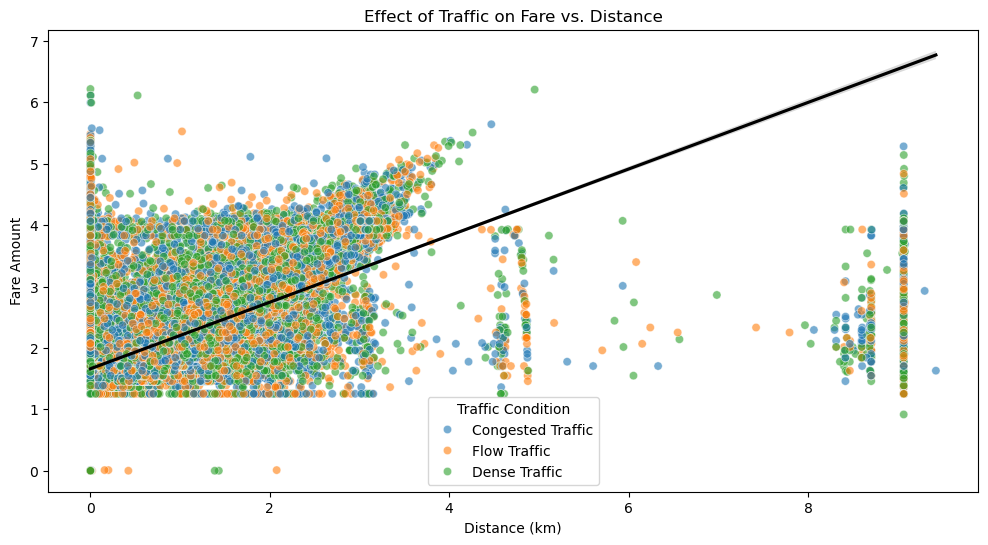

In [288]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x="distance", y="fare_amount", hue="Traffic Condition", data=df, alpha=0.6)
sns.regplot(x="distance", y="fare_amount", data=df, scatter=False, color="black")
plt.xlabel("Distance (km)")
plt.ylabel("Fare Amount")
plt.title("Effect of Traffic on Fare vs. Distance")
plt.show()

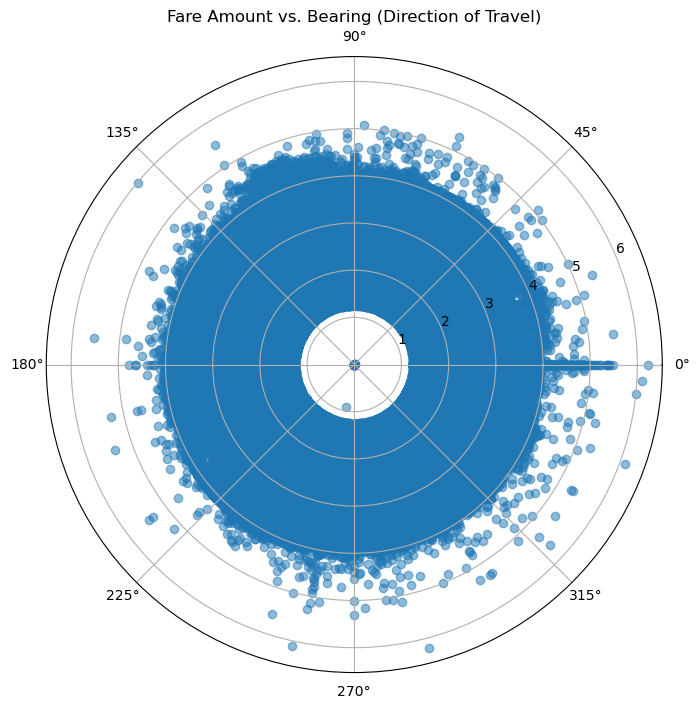

In [289]:
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection='polar')
ax.scatter(df['bearing'], df['fare_amount'], alpha=0.5)
ax.set_title("Fare Amount vs. Bearing (Direction of Travel)")
plt.show()

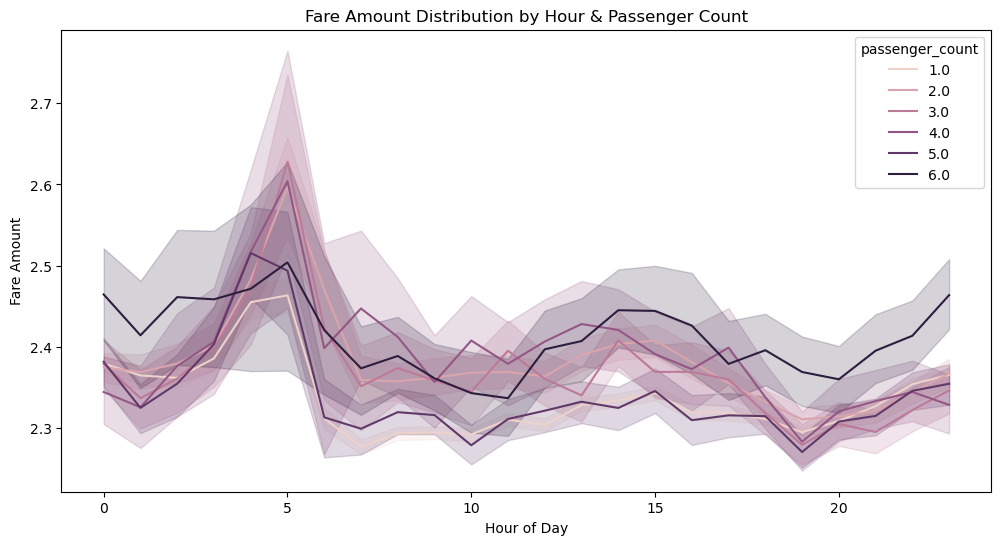

In [290]:
plt.figure(figsize=(12, 6))
sns.lineplot(x="hour", y="fare_amount", hue="passenger_count", data=df)
plt.xlabel("Hour of Day")
plt.ylabel("Fare Amount")
plt.title("Fare Amount Distribution by Hour & Passenger Count")
plt.show()

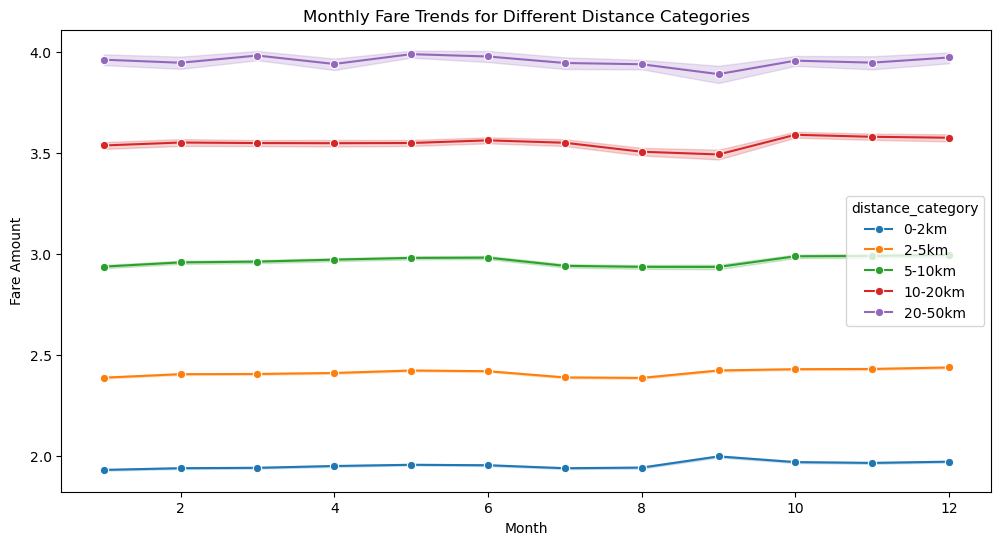

In [294]:
df['distance_category'] = pd.cut(df['distance'], bins=[np.log(1+0), np.log(1+2), np.log(1+5), np.log(1+10), np.log(1+20), np.log(1+50)], labels=['0-2km', '2-5km', '5-10km', '10-20km', '20-50km'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="month", y="fare_amount", hue="distance_category", marker="o")
plt.xlabel("Month")
plt.ylabel("Fare Amount")
plt.title("Monthly Fare Trends for Different Distance Categories")
plt.show()


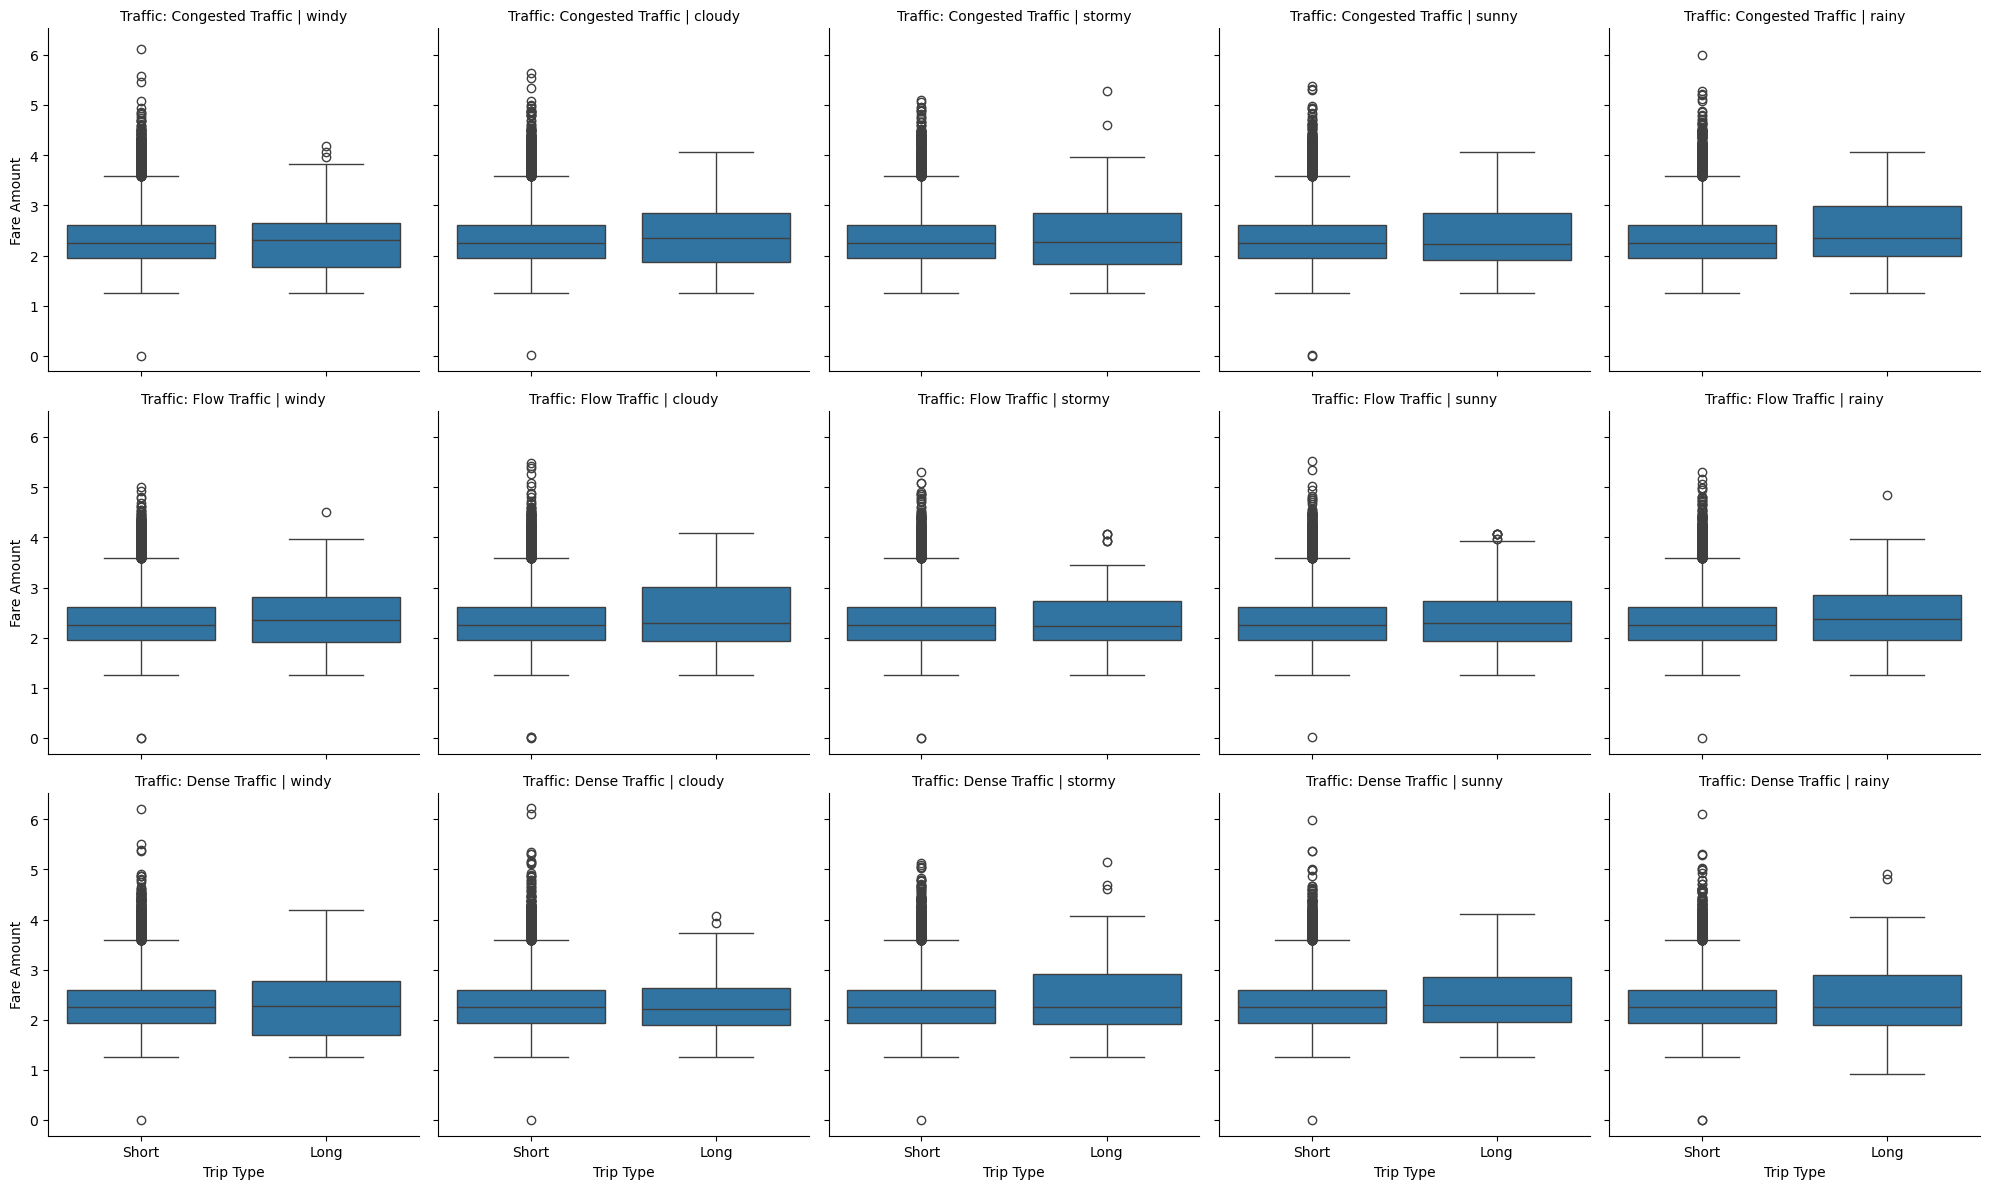

In [292]:
df['trip_type'] = df['distance'].apply(lambda x: 'Short' if x < 5 else 'Long')

g = sns.FacetGrid(df, col="Weather", row="Traffic Condition", height=4)
g.map_dataframe(sns.boxplot, x="trip_type", y="fare_amount", order=["Short", "Long"])
g.set_axis_labels("Trip Type", "Fare Amount")
g.set_titles(col_template="{col_name}", row_template="Traffic: {row_name}")
plt.show()

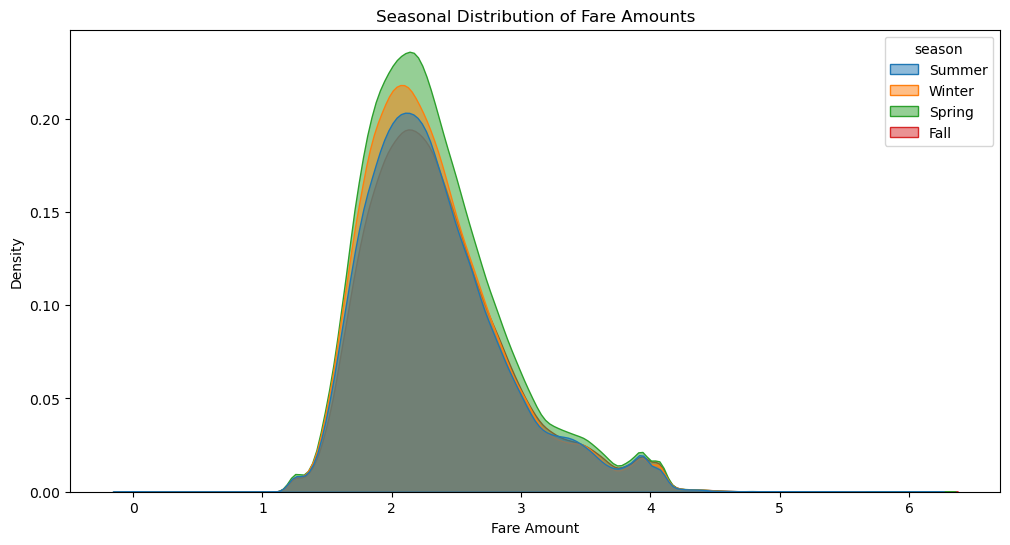

In [293]:
df["season"] = df["month"].map({12: "Winter", 1: "Winter", 2: "Winter",
                                3: "Spring", 4: "Spring", 5: "Spring",
                                6: "Summer", 7: "Summer", 8: "Summer",
                                9: "Fall", 10: "Fall", 11: "Fall"})

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x="fare_amount", hue="season", fill=True, alpha=0.5)
plt.xlabel("Fare Amount")
plt.title("Seasonal Distribution of Fare Amounts")
plt.show()